## Panel of the information on the design
- with respect to:
- Number of genes per gene set
- proportion of expressed genes per gene set
- Number of elements per gene per gene set (density)
- Number of SCREEN brain cCREs per gene per gene set (~does this correlate with the absolute activity of the elements per gene?)

In [1]:
import ast
import sys
import pandas as pd
import numpy as np  # For potential NaN handling if needed
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math


sys.path.append("../00_helpful_functions")
import helpful_functions as hf

# from importlib import reload
# reload(hf)

# column names
col_name = "name"
col_header = "name"
col_sequence = "sequence"
col_category = "category"
col_class = "class"
col_source = "source"
col_ref = "ref"
col_chr = "chr"
col_start = "start"
col_end = "end"
col_strand = "strand"
col_variant_class = "variant_class"
col_variant_pos = "variant_pos"
col_SPDI = "SPDI"
col_allele = "allele"
col_info = "info"


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

import yaml

config_path = "../cCRE_based_analysis/data/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

_SIG_REGION_LEVEL = 0.05

In [2]:
# sanity check until e2g:
element_output = "data/all_80k_MPRA_elements_annotations_table_2606_eQTL_phastCons_ReMap.tsv.gz"
element_output_df = pd.read_csv(element_output, sep="\t")
# example row
example_row = element_output_df.iloc[0]

# eval list like columns
list_list_cols = []
for col in element_output_df.columns:
    if (
        example_row[col]
        and isinstance(example_row[col], str)
        and "[" in example_row[col]
    ):
        list_list_cols.append(col)

for col in list_list_cols:
    element_output_df[col] = element_output_df[
        col
    ].apply(hf.safe_eval)

# rename gene_name to associated_gene_name
element_output_df = element_output_df.rename(columns={"gene_name": "associated_gene_name"})

/tmp/ipykernel_733869/417250093.py:3: DtypeWarning: Columns (0: source, 1: variant_class, 2: variant_pos, 3: SPDI, 4: allele, 5: info, 6: brain_eQTL_gene_symbols) have mixed types. Specify dtype option on import or set low_memory=False.
  element_output_df = pd.read_csv(element_output, sep="\t")


In [3]:
# missing gene:CHRM2
chrm2_rows = element_output_df[
    element_output_df["associated_gene_name"] == "CHRM2"
].copy()
print(f"Number of rows for CHRM2: {len(chrm2_rows)}")
print(f"Number of rows for CHRM2 with a functional readout: {len(chrm2_rows.loc[chrm2_rows['adj.P.Val'].notna()])}")

Number of rows for CHRM2: 8
Number of rows for CHRM2 with a functional readout: 0


In [4]:
tested_ngn2_element_activity_df = element_output_df.loc[element_output_df["name"].str.contains("cardiac_neuro_cava_random") & element_output_df["significant_region_NGN2"].notna()].copy()

In [5]:
print(tested_ngn2_element_activity_df.sample(n=3).to_string())

                                                                                                                                           name                                                                                                                                                                                                                                                                        sequence category class source     ref   chr       start         end strand variant_class variant_pos                           SPDI   allele info                                                                                                                           normalized_name     logFC  adj.P.Val  normalized_activity_NGN2 significant_region_NGN2 effect_direction_NGN2             region_info brain_e2g_cell_type brain_e2g_gene_name brain_e2g_score brain_e2g_distance_to_TSS                        cardiac_e2g_cell_type cardiac_e2g_gene_name   cardiac_e2g_score cardiac_e2g_distance_t

In [6]:
tested_ngn2_element_activity_measured_df = tested_ngn2_element_activity_df.loc[
    tested_ngn2_element_activity_df["normalized_activity_NGN2"].notna()
].copy()
tested_ngn2_element_activity_measured_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,brain_eQTL_fraction_positive,brain_eQTL_direction_consistency,has_overlapping_brain_eQTL,REMAP2022_TFBS_list,REMAP2022_number_of_TFBS,REMAP2022_n_unique_TFBS,phastCons_sum,phastCons_mean0,phastCons_mean,singleton_overlap_count
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,NaN,NaN,False,"[ZNF341, ESR1, DNMT3B, KLF5, EZH2, MLLT1, HEXI...",13,13,2.745,0.010167,0.010167,37.0
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,NaN,NaN,False,"[RBFOX2, BRD1, EZH2, HEXIM1, AGO1, PCBP1, RBM2...",28,28,36.192,0.134044,0.134044,31.0
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,NaN,NaN,False,"[PAF1, RBFOX2, NFATC3, SIRT6, TAF15, NCAPH2, H...",19,19,12.664,0.046904,0.046904,34.0
5,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636.0,2192906.0,+,...,NaN,NaN,False,"[HDGF, ZNF770, TP63, KLF8, ZNF3, HIC1, BCOR, Z...",17,17,0.278,0.001030,0.001030,37.0
7,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380.0,2203650.0,+,...,NaN,NaN,False,"[MED1, SIRT6, HIVEP1, KLF1, HEXIM1, MYOCD, MYO...",24,24,0.112,0.000415,0.000415,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,NaN,NaN,False,"[L3MBTL2, SS18-SSX, BRD3, SMARCA4, ARID4A, KMT...",27,27,1.735,0.006426,0.006426,24.0
73936,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,NaN,NaN,False,"[EP300, SS18-SSX, GATA4, FOXA2, NR3C1, CREBBP,...",15,15,8.954,0.033163,0.033163,23.0
73937,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,NaN,NaN,False,"[ZNF3, CBFA2T2, GRHL2, HDGF, ERG, TAF1, DNMT3B...",17,17,47.159,0.174663,0.174663,17.0
73938,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,NaN,NaN,False,"[ZNF3, CBFA2T2, GRHL2, HDGF, ERG, TAF1, DNMT3B...",17,17,47.159,0.174663,0.174663,17.0


In [7]:
# print(tested_ngn2_element_activity_measured_df.head(n=2).to_string())
print(
    tested_ngn2_element_activity_measured_df[tested_ngn2_element_activity_measured_df['SPDI'].notna()]
    .sample(n=2)
    .to_string()
)

                                                                                                                                         name                                                                                                                                                                                                                                                                        sequence category class source     ref    chr       start         end strand variant_class variant_pos                           SPDI   allele info                                                                                                                         normalized_name     logFC  adj.P.Val  normalized_activity_NGN2 significant_region_NGN2 effect_direction_NGN2              region_info brain_e2g_cell_type brain_e2g_gene_name brain_e2g_score brain_e2g_distance_to_TSS cardiac_e2g_cell_type cardiac_e2g_gene_name cardiac_e2g_score cardiac_e2g_distance_to_TSS             gene_id c

In [8]:
regions_tested_80k_mpra = tested_ngn2_element_activity_measured_df.loc[
    (tested_ngn2_element_activity_measured_df["normalized_activity_NGN2"].notna())
    & ((~tested_ngn2_element_activity_measured_df["name"].str.contains(":ALT_")))
].copy()
regions_tested_80k_mpra

,name,sequence,category,class,source,ref,chr,start,end,strand,...,brain_eQTL_fraction_positive,brain_eQTL_direction_consistency,has_overlapping_brain_eQTL,REMAP2022_TFBS_list,REMAP2022_number_of_TFBS,REMAP2022_n_unique_TFBS,phastCons_sum,phastCons_mean0,phastCons_mean,singleton_overlap_count
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,NaN,NaN,False,"[ZNF341, ESR1, DNMT3B, KLF5, EZH2, MLLT1, HEXI...",13,13,2.745,0.010167,0.010167,37.0
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,NaN,NaN,False,"[RBFOX2, BRD1, EZH2, HEXIM1, AGO1, PCBP1, RBM2...",28,28,36.192,0.134044,0.134044,31.0
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,NaN,NaN,False,"[PAF1, RBFOX2, NFATC3, SIRT6, TAF15, NCAPH2, H...",19,19,12.664,0.046904,0.046904,34.0
5,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636.0,2192906.0,+,...,NaN,NaN,False,"[HDGF, ZNF770, TP63, KLF8, ZNF3, HIC1, BCOR, Z...",17,17,0.278,0.001030,0.001030,37.0
7,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380.0,2203650.0,+,...,NaN,NaN,False,"[MED1, SIRT6, HIVEP1, KLF1, HEXIM1, MYOCD, MYO...",24,24,0.112,0.000415,0.000415,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27559,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466.0,154519736.0,-,...,NaN,NaN,False,"[HDAC2, ARNT, ARID2, SOX6, SMARCA4, HDAC1, SMA...",38,38,13.661,0.050596,0.050596,24.0
27562,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055.0,154539325.0,-,...,NaN,NaN,False,"[YY1, SS18-SSX, TCF12, PRDM1, NFE2L2, MED1, CT...",22,22,6.769,0.025070,0.025070,19.0
27563,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,NaN,NaN,False,"[L3MBTL2, SS18-SSX, BRD3, SMARCA4, ARID4A, KMT...",27,27,1.735,0.006426,0.006426,24.0
27564,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,NaN,NaN,False,"[EP300, SS18-SSX, GATA4, FOXA2, NR3C1, CREBBP,...",15,15,8.954,0.033163,0.033163,23.0


In [9]:
regions_tested_80k_mpra.columns.to_list()

['name',
 'sequence',
 'category',
 'class',
 'source',
 'ref',
 'chr',
 'start',
 'end',
 'strand',
 'variant_class',
 'variant_pos',
 'SPDI',
 'allele',
 'info',
 'normalized_name',
 'logFC',
 'adj.P.Val',
 'normalized_activity_NGN2',
 'significant_region_NGN2',
 'effect_direction_NGN2',
 'region_info',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'gene_id',
 'closest_tss_gene_name',
 'tss_distance',
 'associated_gene_name',
 'gene_set',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'dELS_is_brain_SCREEN_cCRE_group',
 'CA-only_is_brain_SCREEN_cCRE_group',
 'PLS_is_brain_SCREEN_cCRE_group',
 'pELS_is_brain_SCREEN_cCRE_group',
 'CA-H3K4me3_is_brain_SCREEN_cCRE_group',
 'CA-TF_is_brain_SCREEN_cCRE_group',
 'CA-only_is_heart_SCREEN_cCRE_group',
 'PLS_is_heart_SCREEN

In [10]:
all_genes_regions_80k = set(regions_tested_80k_mpra["associated_gene_name"].to_list())
all_genes_measured_80k = set(tested_ngn2_element_activity_measured_df["associated_gene_name"].to_list())
all_genes_80k = set(tested_ngn2_element_activity_df["associated_gene_name"].to_list())

print(f"Number of unique genes in regions tested: {len(all_genes_regions_80k)}")
print(f"Number of unique genes in 80K dataset: {len(all_genes_80k)}")
print(f"Missing genes in regions tested: {len(all_genes_80k - all_genes_regions_80k)} ({all_genes_80k - all_genes_regions_80k})")

Number of unique genes in regions tested: 524
Number of unique genes in 80K dataset: 524
Missing genes in regions tested: 0 (set())


In [11]:
tested_ngn2_element_activity_df.columns.to_list()

['name',
 'sequence',
 'category',
 'class',
 'source',
 'ref',
 'chr',
 'start',
 'end',
 'strand',
 'variant_class',
 'variant_pos',
 'SPDI',
 'allele',
 'info',
 'normalized_name',
 'logFC',
 'adj.P.Val',
 'normalized_activity_NGN2',
 'significant_region_NGN2',
 'effect_direction_NGN2',
 'region_info',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'gene_id',
 'closest_tss_gene_name',
 'tss_distance',
 'associated_gene_name',
 'gene_set',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'dELS_is_brain_SCREEN_cCRE_group',
 'CA-only_is_brain_SCREEN_cCRE_group',
 'PLS_is_brain_SCREEN_cCRE_group',
 'pELS_is_brain_SCREEN_cCRE_group',
 'CA-H3K4me3_is_brain_SCREEN_cCRE_group',
 'CA-TF_is_brain_SCREEN_cCRE_group',
 'CA-only_is_heart_SCREEN_cCRE_group',
 'PLS_is_heart_SCREEN



#### Investigate gene number per gene set:


In [12]:
# get a gene centric dataframe: for each gene the gene set it belongs to and how many regions are associated with it
gene_centric_ref_and_alt_df = (
    tested_ngn2_element_activity_df[["associated_gene_name", "gene_set", "significant_region_NGN2"]]
    .explode("associated_gene_name")
    .explode("gene_set")
    .dropna(subset=["associated_gene_name", "gene_set"])
    .groupby("associated_gene_name")
    .agg({"gene_set": lambda x: list(set(x)), "associated_gene_name": "count", "significant_region_NGN2": "sum"})
    .rename(columns={"associated_gene_name": "num_regions", "significant_region_NGN2": "num_significant_regions"})
    .reset_index()
)
gene_centric_ref_and_alt_df

,associated_gene_name,gene_set,num_regions,num_significant_regions
0,AARS1,[neuro],25,1
1,ABCC9,[cardiac],82,13
2,ABL1,[cardiac],144,1
3,ACTB,[neuro],108,11
4,ACTC1,[cardiac],109,7
...,...,...,...,...
519,ZIC3,[cardiac],27,0
520,ZMYND8,[neuro],81,4
521,ZNF148,[neuro],114,2
522,ZNF292,[neuro],58,8


In [13]:
# get a gene centric dataframe: for each gene the gene set it belongs to and how many regions are associated with it
gene_centric_df = (
    regions_tested_80k_mpra[["associated_gene_name", "gene_set", "significant_region_NGN2"]]
    .explode("associated_gene_name")
    .explode("gene_set")
    .dropna(subset=["associated_gene_name", "gene_set"])
    .groupby("associated_gene_name")
    .agg({"gene_set": lambda x: list(set(x)), "associated_gene_name": "count", "significant_region_NGN2": "sum"})
    .rename(columns={"associated_gene_name": "num_regions", "significant_region_NGN2": "num_significant_regions"})
    .reset_index()
)
gene_centric_df

,associated_gene_name,gene_set,num_regions,num_significant_regions
0,AARS1,[neuro],14,1
1,ABCC9,[cardiac],31,5
2,ABL1,[cardiac],62,1
3,ACTB,[neuro],32,3
4,ACTC1,[cardiac],30,4
...,...,...,...,...
519,ZIC3,[cardiac],18,0
520,ZMYND8,[neuro],48,3
521,ZNF148,[neuro],58,2
522,ZNF292,[neuro],27,2


In [14]:
gene_centric_df["num_regions"].describe()

count    524.000000
mean      48.727099
std       49.870386
min        1.000000
25%       23.000000
50%       34.000000
75%       54.000000
max      404.000000
Name: num_regions, dtype: float64

In [15]:
gene_centric_df["num_significant_regions"].describe()

count     524
unique     22
top         1
freq      105
Name: num_significant_regions, dtype: int64

In [16]:
gene_centric_df["gene_set_str"] = gene_centric_df["gene_set"].apply(lambda x: ", ".join(x))
gene_set_counts = gene_centric_df["gene_set_str"].value_counts()
gene_set_counts

gene_set_str
neuro                   292
cardiac                 149
cava                     41
random                   25
cardiac, neuro           10
neuro, cava               3
cardiac, cava             3
cardiac, neuro, cava      1
Name: count, dtype: int64

In [17]:
# how many regions near neuro, cardiac and cava genes:
gene_centric_df["is_neuro"] = gene_centric_df["gene_set"].apply(lambda x: "neuro" in x)
gene_centric_df["is_cardiac"] = gene_centric_df["gene_set"].apply(lambda x: "cardiac" in x)
gene_centric_df["is_cava"] = gene_centric_df["gene_set"].apply(lambda x: "cava" in x)
gene_centric_df["is_random"] = gene_centric_df["gene_set"].apply(lambda x: "random" in x)
gene_centric_df

# present number of regions per gene set in a table:
gene_set_summary = gene_centric_df.groupby("gene_set_str").agg(
    num_genes=("associated_gene_name", "nunique"),
    total_regions=("num_regions", "sum"),
    avg_regions_per_gene=("num_regions", "mean"),
).reset_index()
gene_set_summary

,gene_set_str,num_genes,total_regions,avg_regions_per_gene
0,cardiac,149,6802,45.651007
1,"cardiac, cava",3,188,62.666667
2,"cardiac, neuro",10,1530,153.000000
3,"cardiac, neuro, cava",1,30,30.000000
4,cava,41,1505,36.707317
5,neuro,292,14522,49.732877
6,"neuro, cava",3,288,96.000000
7,random,25,668,26.720000




           gene_set_str  num_genes  total_regions  avg_regions_per_gene
0               cardiac        149           6802             45.651007
1        cardiac, neuro         10           1530            153.000000
2                  cava         41           1505             36.707317
3         cava, cardiac          3            188             62.666667
4           cava, neuro          3            288             96.000000
5  cava, neuro, cardiac          1             30             30.000000
6                 neuro        292          14522             49.732877
7                random         25            668             26.720000

In [18]:
print(gene_set_summary.to_string())

           gene_set_str  num_genes  total_regions  avg_regions_per_gene
0               cardiac        149           6802             45.651007
1         cardiac, cava          3            188             62.666667
2        cardiac, neuro         10           1530            153.000000
3  cardiac, neuro, cava          1             30             30.000000
4                  cava         41           1505             36.707317
5                 neuro        292          14522             49.732877
6           neuro, cava          3            288             96.000000
7                random         25            668             26.720000


In [19]:
# writing supplementary table:
output_path = "data/supplementary/gene_info_supplementary_table.xlsx"
writing = False
if writing:
    # writing gene set summary to sheet 2:
    with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        gene_centric_df[["associated_gene_name", "gene_set_str", "num_regions"]].rename(columns={"associated_gene_name": "gene_name"}).to_excel(writer, sheet_name="Sheet1", index=False)
        gene_set_summary.to_excel(writer, sheet_name="gene_set_summary", index=False)


#            gene_set_str  num_genes  total_regions  proportion_regions
# 0               cardiac        149           6802            0.266400
# 1        cardiac, neuro         10           1530            0.059922
# 2                  cava         41           1505            0.058943
# 3         cava, cardiac          3            188            0.007363
# 4  cava, cardiac, neuro          1             30            0.001175
# 5           cava, neuro          3            288            0.011280
# 6                 neuro        292          14522            0.568754
# 7                random         25            668            0.026162

In [20]:
# present the proportion of the number of regions associated with each gene set:
total_regions_all_genes = gene_centric_df["num_regions"].sum()
gene_set_summary["proportion_regions"] = gene_set_summary["total_regions"] / total_regions_all_genes
print(f"Number of all regions: {total_regions_all_genes}")
gene_set_summary

Number of all regions: 25533


,gene_set_str,num_genes,total_regions,avg_regions_per_gene,proportion_regions
0,cardiac,149,6802,45.651007,0.266400
1,"cardiac, cava",3,188,62.666667,0.007363
2,"cardiac, neuro",10,1530,153.000000,0.059922
3,"cardiac, neuro, cava",1,30,30.000000,0.001175
4,cava,41,1505,36.707317,0.058943
5,neuro,292,14522,49.732877,0.568754
6,"neuro, cava",3,288,96.000000,0.011280
7,random,25,668,26.720000,0.026162


In [21]:
metadata_file_path = config["files"]["creating"]["metadata_corrected_spdi_202511"]
metadata_file = pd.read_csv(metadata_file_path, sep="\t")
metadata_file
# read in with respect to lists

# example row
example_row = metadata_file.loc[metadata_file["name"] == "cardiac_neuro_cava_random:ALT_SKI|ENSG00000157933.11|EH38E2778782_fwd_tile1-1_SKI|ENSG00000157933.11|EH38E2778782|1-2345557-C-T"].iloc[0]

# eval list like columns
list_list_cols = []
for col in metadata_file.columns:
    if (
        example_row[col]
        and isinstance(example_row[col], str)
        and "[" in example_row[col]
    ):
        list_list_cols.append(col)

for col in list_list_cols:
    metadata_file[col] = metadata_file[
        col
    ].apply(hf.safe_eval)

/tmp/ipykernel_733869/3262766607.py:2: DtypeWarning: Columns (0: source, 1: info) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_file = pd.read_csv(metadata_file_path, sep="\t")


In [22]:
metadata_file

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,None,None,None,None,NaN
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,None,None,None,None,NaN
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,None,None,None,None,NaN
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,None,None,None,None,NaN
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,None,None,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,MK:tile_2240|chr1-116244322+116244591|scramble...,CTTAATCAAATAACCCATTAATTCTATATATCTACCTAATATTAAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr1,116244322.0,116244591.0,+,None,None,None,None,NaN
80211,MK:tile_6675|chr11-2374617+2374886|scramble_ne...,CATCGGCCCTGGTGAAGCGTCCGTCCAGACGGGCCTGCCTAGCCTC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr11,2374617.0,2374886.0,+,None,None,None,None,NaN
80212,MK:tile_18415|chr17-71181691+71181960|scramble...,TAAATATTCAGCGATACATTCCTATTCTTTTTCAGAAGTAGTTATT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr17,71181691.0,71181960.0,+,None,None,None,None,NaN
80213,MK:tile_14356|chr15-67031618+67031887|scramble...,TGAAGCCCCTGATTCTGTTAGAATAAGGTTACTGAGTCGTGTATAC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr15,67031618.0,67031887.0,+,None,None,None,None,NaN


In [23]:
def get_gene_name(header, with_controls=True):
    """Returns the gene name: cardiac_neuro_cava_random:SKI|ENSG00000157933.11|EH38E2778533_fwd_tile1-1 => SKI"""
    if "cardiac_neuro_cava_random" not in header:
        if not with_controls:
            print(header)
            raise ValueError("Function only defined for tested headers")
        return "Not given - control sequence"

    if "ALT_" in header:
        return header.split(":ALT_")[1].split("|")[0]

    if "REF_" in header:
        return header.split(":REF_")[1].split("|")[0]

    return header.split(":")[1].split("|")[0]


from collections import defaultdict


def get_gene_lookup_dict(
    gene_lists,
    gene_list_dir="data/gene_lists",
):
    """
    prepare a dict which has gene_name: (list of associated gene_sets)
    :gene_lists - list of files containing gene names and have useful names
    """
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), "r") as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split(".")[0]
            for gene in gene_list:
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict

import re

def extract_eh38e_number(header):
    # Use regex to find the pattern that starts with EH38E followed by digits
    match = re.search(r"EH38E\d+", header)
    if match:
        return match.group(0)  # Return the matched string
    return None  # Return None if no match is found

In [24]:
disease_regions_80k_mpra = metadata_file.loc[
    (metadata_file["name"].str.contains(
        "cardiac_neuro_cava_random:",
        case=False,
    )) & (~metadata_file["name"].str.contains(":ALT_", case=False))
].copy()
disease_regions_80k_mpra

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,None,None,None,None,NaN
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,None,None,None,None,NaN
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,None,None,None,None,NaN
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,None,None,None,None,NaN
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,None,None,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27561,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCCAAGCCCATCC...,variant,test,NaN,GRCh38,chrX,154531979.0,154532249.0,-,"[SNV, SNV, SNV, SNV]","[62, 117, 177, 234]","[NC_000023.11:154532041:C:G, NC_000023.11:1545...","[ref, ref, ref, ref]",NaN
27562,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055.0,154539325.0,-,"[SNV, SNV, SNV, SNV]","[121, 160, 185, 194]","[NC_000023.11:154539176:A:G, NC_000023.11:1545...","[ref, ref, ref, ref]",NaN
27563,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,[SNV],[205],[NC_000023.11:154545205:A:G],[ref],NaN
27564,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,[SNV],[120],[NC_000023.11:154549922:T:G],[ref],NaN


In [25]:
# get gene_list files:
gene_list_dir = "data/gene_lists"
gene_lists = os.listdir(gene_list_dir)

# drop the gene lists without .txt ending:
gene_lists = [gene_list for gene_list in gene_lists if gene_list.endswith(".txt")]
gene_lists

# prepare a dict which has gene_name: (tuple of associated gene_sets)
gene_lookup_dict = get_gene_lookup_dict(gene_lists=gene_lists)

In [26]:
# # get gene name from variant id
disease_regions_80k_mpra["associated_gene_name"] = disease_regions_80k_mpra[
    "name"
].apply(lambda x: get_gene_name(x, with_controls=False))

disease_regions_80k_mpra["gene_set"] = disease_regions_80k_mpra[
    "associated_gene_name"
].apply(lambda gene: gene_lookup_dict[gene])


disease_regions_80k_mpra["SCREEN_ID"] = disease_regions_80k_mpra["name"].apply(
    extract_eh38e_number
)

In [27]:
disease_regions_80k_mpra

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,associated_gene_name,gene_set,SCREEN_ID
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778476
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778477
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778478
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778480
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27561,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCCAAGCCCATCC...,variant,test,NaN,GRCh38,chrX,154531979.0,154532249.0,-,"[SNV, SNV, SNV, SNV]","[62, 117, 177, 234]","[NC_000023.11:154532041:C:G, NC_000023.11:1545...","[ref, ref, ref, ref]",NaN,G6PD,[cava],EH38E3949715
27562,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055.0,154539325.0,-,"[SNV, SNV, SNV, SNV]","[121, 160, 185, 194]","[NC_000023.11:154539176:A:G, NC_000023.11:1545...","[ref, ref, ref, ref]",NaN,G6PD,[cava],EH38E3949725
27563,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,[SNV],[205],[NC_000023.11:154545205:A:G],[ref],NaN,G6PD,[cava],EH38E3949733
27564,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,[SNV],[120],[NC_000023.11:154549922:T:G],[ref],NaN,G6PD,[cava],EH38E2774396


In [28]:
number_of_screen_ids = disease_regions_80k_mpra["SCREEN_ID"].value_counts().reset_index()
number_of_screen_ids["count"].describe() # at most 2 times (i.e. both strands)

count    27209.000000
mean         1.010033
std          0.099665
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: count, dtype: float64

In [29]:
print(f"Number of unique screen ids: {disease_regions_80k_mpra['SCREEN_ID'].nunique()}")

Number of unique screen ids: 27209


In [30]:
disease_regions_80k_mpra

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,associated_gene_name,gene_set,SCREEN_ID
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778476
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778477
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778478
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778480
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27561,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCCAAGCCCATCC...,variant,test,NaN,GRCh38,chrX,154531979.0,154532249.0,-,"[SNV, SNV, SNV, SNV]","[62, 117, 177, 234]","[NC_000023.11:154532041:C:G, NC_000023.11:1545...","[ref, ref, ref, ref]",NaN,G6PD,[cava],EH38E3949715
27562,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055.0,154539325.0,-,"[SNV, SNV, SNV, SNV]","[121, 160, 185, 194]","[NC_000023.11:154539176:A:G, NC_000023.11:1545...","[ref, ref, ref, ref]",NaN,G6PD,[cava],EH38E3949725
27563,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,[SNV],[205],[NC_000023.11:154545205:A:G],[ref],NaN,G6PD,[cava],EH38E3949733
27564,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,[SNV],[120],[NC_000023.11:154549922:T:G],[ref],NaN,G6PD,[cava],EH38E2774396


In [31]:
disease_regions_80k_mpra_unqiue = disease_regions_80k_mpra.drop_duplicates(subset=["SCREEN_ID"])
disease_regions_80k_mpra_unqiue

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,associated_gene_name,gene_set,SCREEN_ID
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778476
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778477
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778478
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778480
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,None,None,None,None,NaN,SKI,[neuro],EH38E2778484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27561,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCCAAGCCCATCC...,variant,test,NaN,GRCh38,chrX,154531979.0,154532249.0,-,"[SNV, SNV, SNV, SNV]","[62, 117, 177, 234]","[NC_000023.11:154532041:C:G, NC_000023.11:1545...","[ref, ref, ref, ref]",NaN,G6PD,[cava],EH38E3949715
27562,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055.0,154539325.0,-,"[SNV, SNV, SNV, SNV]","[121, 160, 185, 194]","[NC_000023.11:154539176:A:G, NC_000023.11:1545...","[ref, ref, ref, ref]",NaN,G6PD,[cava],EH38E3949725
27563,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,[SNV],[205],[NC_000023.11:154545205:A:G],[ref],NaN,G6PD,[cava],EH38E3949733
27564,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,[SNV],[120],[NC_000023.11:154549922:T:G],[ref],NaN,G6PD,[cava],EH38E2774396


In [32]:
disease_regions_80k_mpra_unqiue["gene_set"].value_counts()

gene_set
[neuro]                   16151
[cardiac]                  7546
[cava]                     1610
[neuro, cardiac]            866
[random]                    717
[neuro, cava]               179
[cava, cardiac]             111
[neuro, cava, cardiac]       29
Name: count, dtype: int64

In [33]:
# get a gene centric dataframe: for each gene the gene set it belongs to and how many regions are associated with it
gene_centric_df_full_design = (
    disease_regions_80k_mpra_unqiue[["associated_gene_name", "gene_set"]]
    .explode("associated_gene_name")
    .explode("gene_set")
    .dropna(subset=["associated_gene_name", "gene_set"])
    .groupby("associated_gene_name")
    .agg({"gene_set": lambda x: list(set(x)), "associated_gene_name": "count"})
    .rename(columns={"associated_gene_name": "num_regions"})
    .reset_index()
)
gene_centric_df_full_design

,associated_gene_name,gene_set,num_regions
0,AARS1,[neuro],14
1,ABCC9,[cardiac],33
2,ABL1,[cardiac],68
3,ACTB,[neuro],45
4,ACTC1,[cardiac],32
...,...,...,...
519,ZIC3,[cardiac],26
520,ZMYND8,[neuro],51
521,ZNF148,[neuro],60
522,ZNF292,[neuro],28


In [34]:
gene_centric_df_full_design["gene_set_str"] = gene_centric_df_full_design[
    "gene_set"
].apply(lambda x: ", ".join(x))

In [35]:
# present number of regions per gene set in a table:
gene_set_summary_full_design = (
    gene_centric_df_full_design.groupby("gene_set_str")
    .agg(
        num_genes=("associated_gene_name", "nunique"),
        total_regions=("num_regions", "sum"),
        avg_regions_per_gene=("num_regions", "mean"),
    )
    .reset_index()
)
gene_set_summary_full_design

,gene_set_str,num_genes,total_regions,avg_regions_per_gene
0,cardiac,149,7546,50.644295
1,"cardiac, cava",3,222,74.000000
2,"cardiac, neuro",10,1732,173.200000
3,"cardiac, neuro, cava",1,87,87.000000
4,cava,41,1610,39.268293
5,neuro,292,16151,55.311644
6,"neuro, cava",3,358,119.333333
7,random,25,717,28.680000


In [36]:
# present the proportion of the number of regions associated with each gene set:
total_regions_all_genes_full_design = gene_set_summary_full_design["total_regions"].sum()
gene_set_summary_full_design["proportion_regions"] = (
    gene_set_summary_full_design["total_regions"] / total_regions_all_genes_full_design
)
print(f"Number of all regions: {total_regions_all_genes_full_design}")
gene_set_summary_full_design

Number of all regions: 28423


,gene_set_str,num_genes,total_regions,avg_regions_per_gene,proportion_regions
0,cardiac,149,7546,50.644295,0.265489
1,"cardiac, cava",3,222,74.000000,0.007811
2,"cardiac, neuro",10,1732,173.200000,0.060937
3,"cardiac, neuro, cava",1,87,87.000000,0.003061
4,cava,41,1610,39.268293,0.056644
5,neuro,292,16151,55.311644,0.568237
6,"neuro, cava",3,358,119.333333,0.012595
7,random,25,717,28.680000,0.025226




### Annotate with disease information:

In [37]:
sfari_genes = "data/SFARI-Gene-Archive_genes.csv"
sfari_df = pd.read_csv(sfari_genes)
print("unique genes: ", sfari_df["gene-symbol"].nunique())
sfari_df

unique genes:  1006


,status,gene-symbol,gene-name,chromosome,genetic-category,gene-score,syndromic,number-of-reports
0,9,ABCA10,"ATP-binding cassette, sub-family A (ABC1), mem...",17,Rare Single Gene Mutation,4.0,0,1
1,9,ABCA13,ATP binding cassette subfamily A member 13,7,"Rare Single Gene Mutation, Functional",4.0,0,5
2,9,ABCA7,"ATP-binding cassette, sub-family A (ABC1), mem...",19,Rare Single Gene Mutation,4.0,0,2
3,9,ACE,angiotensin I converting enzyme,17,"Rare Single Gene Mutation, Genetic Association",4.0,0,2
4,9,ACHE,Acetylcholinesterase (Yt blood group),7,Rare Single Gene Mutation,3.0,0,4
...,...,...,...,...,...,...,...,...
1001,9,YEATS2,YEATS domain containing 2,3,Genetic Association,4.0,0,1
1002,9,ZNF804A,Zinc finger protein 804A,2,"Rare Single Gene Mutation, Genetic Association",3.0,0,13
1003,9,ZNF827,Zinc finger protein 827,4,Genetic Association,4.0,0,1
1004,9,ZSWIM5,"zinc finger, SWIM-type containing 5",1,Rare Single Gene Mutation,6.0,0,1


In [38]:
sfari_genes = "data/SFARI-Gene_genes_01-14-2026release_01-29-2026export.csv"
sfari_list2_df = pd.read_csv(sfari_genes)
sfari_list2_df = sfari_list2_df.loc[sfari_list2_df["gene-score"] == 1]
print("unique genes: ", sfari_list2_df["gene-symbol"].nunique())

sfari_genes = set(sfari_list2_df["gene-symbol"].to_list())

unique genes:  244


In [39]:
sfari_not_second_but_first_list = set(sfari_list2_df["gene-symbol"].to_list()) - set(sfari_df["gene-symbol"].to_list())
sfari_not_second_but_first_list

{'ABCE1',
 'ACTB',
 'ANP32A',
 'AP2S1',
 'ARF3',
 'CACNA1A',
 'CAMTA2',
 'CHAMP1',
 'CORO1A',
 'CPSF7',
 'CSDE1',
 'CSNK2A1',
 'GABRB2',
 'GFAP',
 'GNAI1',
 'GRIA2',
 'HIVEP2',
 'KANSL1',
 'KDM2B',
 'KDM3B',
 'KIAA0232',
 'KLHL20',
 'LDB1',
 'LRRC4C',
 'MAGEC3',
 'MAP1A',
 'MKX',
 'MSL3',
 'MYCBP2',
 'NCOA1',
 'NUP155',
 'PCCB',
 'PHF12',
 'PPP1R9B',
 'PPP5C',
 'PRMT9',
 'PRR14L',
 'PSMD11',
 'PSMD6',
 'RNU2-2',
 'RNU4-2',
 'RNU5B-1',
 'RORB',
 'RUNX1T1',
 'SATB1',
 'SETD1A',
 'SF1',
 'SKI',
 'SMARCA1',
 'SMARCA2',
 'SON',
 'SOS2',
 'SRPRA',
 'TAOK1',
 'TBCEL',
 'TBCK',
 'TEK',
 'TLE3',
 'TM9SF4',
 'TRIM23',
 'TSHZ1',
 'UBAP2L',
 'UBR1',
 'USP9X',
 'VEZF1',
 'ZBTB21',
 'ZMYND8',
 'ZNF865'}

In [40]:
union_both_lists = sfari_genes | set(sfari_df["gene-symbol"].to_list())
print("union of both lists has ", len(union_both_lists), " unique genes")

union of both lists has  1074  unique genes


In [41]:
# make a gene centric list of the number of regions and combine the gene set information
gene_centric_list = tested_ngn2_element_activity_measured_df.groupby(
    "associated_gene_name"
).agg(
    num_regions=("name", "count"),
    gene_set_str=(
        "gene_set",
        lambda x: x.mode()[0] if len(x.mode()) > 0 else "unknown",
    ),
).reset_index()
gene_centric_list


# dieseases:
# congenital heart disease e.g. TBX5
# coronary artery disease e.g. CDKN2A
# long QT syndrome e.g. NOS1AP
# atrial fibrillation e.g. PRRX1 PITX2
# Brugada syndrome e.g. SCN5A
# cardiomyopathy e.g. MYH7
# obesity e.g. FTO or IRX3

,associated_gene_name,num_regions,gene_set_str
0,AARS1,25,[neuro]
1,ABCC9,82,[cardiac]
2,ABL1,144,[cardiac]
3,ACTB,108,[neuro]
4,ACTC1,109,[cardiac]
...,...,...,...
519,ZIC3,27,[cardiac]
520,ZMYND8,81,[neuro]
521,ZNF148,114,[neuro]
522,ZNF292,58,[neuro]


In [42]:
# how many of the neuron genes are within sfari?
gene_centric_list["is_in_sfari"] = gene_centric_list["associated_gene_name"].isin(
    sfari_genes
)
gene_centric_list["is_in_sfari"].value_counts()

is_in_sfari
False    327
True     197
Name: count, dtype: int64

In [43]:
gene_centric_list

,associated_gene_name,num_regions,gene_set_str,is_in_sfari
0,AARS1,25,[neuro],False
1,ABCC9,82,[cardiac],False
2,ABL1,144,[cardiac],False
3,ACTB,108,[neuro],True
4,ACTC1,109,[cardiac],False
...,...,...,...,...
519,ZIC3,27,[cardiac],False
520,ZMYND8,81,[neuro],True
521,ZNF148,114,[neuro],False
522,ZNF292,58,[neuro],True


In [44]:
# https://docs.google.com/spreadsheets/d/1tyZmnJwkbtq_h1xn2ZGLiEMUMpVJ4-_V/edit?gid=136160754#gid=136160754
# or CHD, CMP - control_options.xlsx - 3. CHD_known_variants_genes.tsv
genes_chd_cmp_and_more_diseases = set([
    "CDKN2A",
    "CDKN2B",
    "CDKN2B-AS1",
    "CDKN2A",
    "BCDKN2B-AS1",
    "PHACTR1",
    "SMAD3",
    "PHACTR1",
    "PLPP3",
    "TBX5",
    "MTRR",
    "GATA4",
    "PBX1",
    "NOS1AP",
    "KCNH2",
    "PRKCA",
    "PITX2c",
    "GJA1KCNN3ZFHX3",
    "PRRX1",
    "SCN10ASCN5A",
    "SCN5A",
    "MYL2MYH7",
    "SCN5A",
    "MYH7",
    "DSG2",
    "FTO",
    "IRX3"
])


# https://docs.google.com/spreadsheets/d/1tyZmnJwkbtq_h1xn2ZGLiEMUMpVJ4-_V/edit?gid=1294951792#gid=1294951792
# or
genes_cmp_second_page = set([
    "ABCC9",
    "ACTC1",
    "ACTN2",
    "ALPK3",
    "ANKRD1",
    "BAG3",
    "BRAF",
    "CALR3",
    "CASQ2",
    "CAV3",
    "CBL",
    "CHRM2",
    "CRYAB",
    "CSRP3",
    "CTNNA3",
    "DES",
    "DMD",
    "DOLK",
    "DSC2",
    "DSG2",
    "DSP",
    "DTNA",
    "EMD",
    "EYA4",
    "FHL1",
    "FHL2",
    "FKRP",
    "FKTN",
    "FLNC",
    "GATAD1",
    "HCN4",
    "HRAS",
    "ILK",
    "JPH2",
    "JUP",
    "KRAS",
    "LAMA4",
    "LAMP2",
    "LDB3",
    "LMNA",
    "MAP2K1",
    "MAP2K2",
    "MYBPC3",
    "MYH6",
    "MYH7",
    "MYL2",
    "MYL3",
    "MYLK2",
    "MYOM1",
    "MYOZ2",
    "MYPN",
    "NEBL",
    "NEXN",
    "NF1",
    "NRAS",
    "PDLIM3",
    "PKP2",
    "PLEKHM2",
    "PLN",
    "PRDM16",
    "PRKAG2",
    "PTPN11",
    "RAF1",
    "RBM20",
    "RIT1",
    "RRAS",
    "RYR2",
    "SCN5A",
    "SGCD",
    "SHOC2",
    "SLC22A5",
    "SLC25A4",
    "SOS1",
    "TCAP",
    "TGFB3",
    "TMEM43",
    "TMEM70",
    "TNNC1",
    "TNNI3",
    "TNNT2",
    "TPM1",
    "TTN",
    "TTR",
    "VCL"
])

# cases CHD genes heartenn >=0.1
heart_enn_genes = set([
    "ECE1",
    "CACNA1C",
    "MED13L",
    "UBR1",
    "TSC2",
    "RAI1",
    "MAP2K2",
    "SMARCA4",
    "SOS1",
    "STAMBP",
    "TBX1",
    "SH3PXD2B",
    "SEMA3E",
    "WDR60",
    "GATA4",
    "ROR2",
    "OFD1",
    "BCOR",
])

In [45]:
gene_info_path = "data/gene_information"
chd_cmp_control_options_path = "chd_cmd_info/CHD, CMP - control_options.xlsx - 2. CMP_regions.csv"
chd_cmp_region_info_df = pd.read_csv(os.path.join(gene_info_path, chd_cmp_control_options_path))
# remove last two rows
chd_cmp_region_info_df = chd_cmp_region_info_df.iloc[:-2]
chd_cmp_region_info_df
chd_cmp_region_info_df_genes = set(chd_cmp_region_info_df["Gene symbol"].to_list())

In [46]:
coronary_artery_disease_genes = set([
    "CDKN2A",
    "CDKN2B",
    "CDKN2B-AS1",
    "CDKN2A",
    "BCDKN2B-AS1",
    "PHACTR1",
    "SMAD3",
    "PHACTR1",
    "PLPP3",
    "CDKN2B-AS1"])

In [47]:
chd_cmp_omim_genes = set([
    "GATA6",
    "NR2F2",
    "TAB2",
    "GDF1",
    "GATA4",
    "TBX5",
    "NKX2-5",
    "GATA5",
    "FLT4",
    "SMAD2",
    "GATA4",
    "FLNA",
    "PIGL",
    "ARHGAP31",
    "GDF1",
    "ABL1",
    "SCN5A"])

In [48]:
# https://docs.google.com/spreadsheets/d/147hMwfc5ZnjkR37g6bLZMbT1hxumi0j3/edit?gid=1926102956#gid=1926102956
cmd_220915 = [
    "VEGFA",
    "CDKN2B",
    "HNF1A",
    "FHL3",
    "NOS3",
    "SMAD3",
    "ZEB1",
    "KLF4",
    "TGFB1",
    "FHL3",
    "NOS3",
    "SMAD3",
    "SMAD2",
    "SMAD6",
    "SNAI2",
    "VEGFA",
    "MAFB",
    "ADAMTS7",
    "ALDH2",
    "MAFB",
    "CDKN2B",
    "FHL3",
    "NOS3",
    "ADAMTS7",
    "ALDH2",
    "SMAD3",
    "SMAD2",
    "SMAD4",
    "SREBF1",
    "SNAI2",
    "KLF4",
    "CDKN2B",
    "HNF1A",
    "SMAD4",
    "SMAD6",
    "TBX5",
    "GATA4",
    "SREBF1",
    "PHACTR1",
    "HNF1A",
    "NKX2.5",
    "TBX5",
    "GATA4",
    "ZEB1",
    "KLF4",
    "PHACTR1",
    "TBX5",
    "GATA4",
    "PRDM16",
    "NKX2.5"
]
cmd_220915_set = set(cmd_220915)

In [49]:
combined_chd_cmp_and_more_heart_disease_genes = (
    genes_chd_cmp_and_more_diseases
    | genes_cmp_second_page
    | heart_enn_genes
    | chd_cmp_region_info_df_genes
    | coronary_artery_disease_genes
    | chd_cmp_omim_genes
    | cmd_220915_set
)
# print length:
print("Combined CHD, CMP and more heart disease genes: ", len(combined_chd_cmp_and_more_heart_disease_genes))
# annotate gene centric now as "CHD_CMP_CAD_more_genes"
gene_centric_list["is_CHD_CMP_CAD_more_genes"] = gene_centric_list["associated_gene_name"].isin(
    combined_chd_cmp_and_more_heart_disease_genes
)
gene_centric_list["is_CHD_CMP_CAD_more_genes"].value_counts()

Combined CHD, CMP and more heart disease genes:  149


is_CHD_CMP_CAD_more_genes
False    386
True     138
Name: count, dtype: int64

In [50]:
# https://docs.google.com/spreadsheets/d/1UGT3mE4l_I7s351m7SvfaVhezCbAqHsT/edit?gid=421688455#gid=421688455
# or /home/kisa/coding/80K_MPRA/gene_information/neurological_phenotyp_genes/NPCs_control_options.xlsx - Global Developmental Delay.tsv
developmental_delay_genes = set([
    "OXR1",
    "ZNF148",
    "DICER1",
    "CUX1",
    "GLS",
    "TNRC6B"
])

# https://docs.google.com/spreadsheets/d/1UGT3mE4l_I7s351m7SvfaVhezCbAqHsT/edit?gid=1766480851#gid=1766480851
# or /home/kisa/coding/80K_MPRA/gene_information/neurological_phenotyp_genes/NPCs_control_options.xlsx - ASD.tsv
asd_genes = set([
    "AUTS11",
    "TBR1",
    "IDDAS",
    "SLC9A9",
    "AUTS16",
    "AUTS8",
    "NLGN1",
    "EIF4E",
    "EIF4EL1",
    "AUTS19",
    "AUTS1",
    "AUTS9",
    "CNTNAP2",
    "CASPR2",
    "NRXN4",
    "AUTS15",
    "PTHSL1",
    "AUTS10",
    "SHANK2",
    "CORTBP1",
    "AUTS17",
    "AUTS13",
    "AUTS3",
    "CHD8",
    "DUPLIN",
    "KIAA1564",
    "IDDAM",
    "AUTS4",
    "DEL16",
    "C16DEL",
    "AUTS14A",
    "DEL16",
    "C16DEL",
    "AUTS14A",
    "AUTS6",
    "AUTS7",
    "AUTS12",
    "NLGN4",
    "KIAA1260",
    "AUTSX2",
    "ASPGX2",
    "NLGN4",
    "KIAA1260",
    "AUTSX2",
    "ASPGX2",
    "PTCHD1",
    "AUTSX4",
    "NLGN3",
    "ASPGX1",
    "AUTSX1",
    "MECP2",
    "RTT",
    "PPMX",
    "AUTSX3",
    "MRXSL",
    "MRXS13",
    "RPL10",
    "DXS648",
    "QM",
    "AUTSX5",
    "MRXS35",
    "TMLHE",
    "BBOX2",
    "TMLH",
    "TMLHED",
    "AUTSX6",
])

# https://docs.google.com/spreadsheets/d/1UGT3mE4l_I7s351m7SvfaVhezCbAqHsT/edit?gid=1945784398#gid=1945784398
# or NPCs_control_options.xlsx - ASD_SFARI.tsv
asd_sfari_genes_table = pd.read_csv(
    "data/NPCs_control_options.xlsx - ASD_SFARI.tsv",
    sep="\t",
)
asd_sfari_genes_set = set(asd_sfari_genes_table["gene-symbol"].to_list())


# https://docs.google.com/spreadsheets/d/1UGT3mE4l_I7s351m7SvfaVhezCbAqHsT/edit?gid=1619305704#gid=1619305704
schizophrenia_genes = set(
    [
        "SCZD12",
        "MTHFR",
        "CHI3L1",
        "DISC2",
        "SYN2",
        "DRD3",
        "SCZD1",
        "SCZD3",
        "SCZD5",
        "SCZD6",
        "SCZD11",
        "SCZD2",
        "HTR2A",
        "SCZD7",
        "DAOA",
        "SCZD8",
        "COMT",
        "RTN4R",
        "APOL4",
        "APOL2",
        "PRODH",
    ]
)

adhd_genes = set([
    "DRD5",
    "DRD4",
    "TPH2",
    "CDH2",
])

In [51]:
epileptic_encephalophathy_genes = set([
    "SZT2",
    "KIAA0467",
    "DEE18",
    "ST3GAL3",
    "SIAT6",
    "ST3GALII",
    "MRT12",
    "DEE15",
    "PARS2",
    "DEE75",
    "DOCK7",
    "KIAA1771",
    "DEE23",
    "KCNA2",
    "DEE32",
    "ATP1A2",
    "FHM2",
    "MHP2",
    "FARIMPD",
    "DEE98",
    "CACNA1E",
    "CACNL1A6",
    "DEE69",
    "KCNT2",
    "SLICK",
    "DEE57",
    "FBXO28",
    "FBX28",
    "KIAA0483",
    "DEE100",
    "ARV1",
    "DEE38",
    "HNRNPU",
    "HNRPU",
    "SAFA",
    "DEE54",
    "CAD",
    "CDG1Z",
    "DEE50",
    "MDH1",
    "DEE88",
    "KAR",
    "UGP2",
    "UGPP2",
    "DEE83",
    "SCN3A",
    "FFEVF4",
    "DEE62",
    "SCN2A",
    "SCN2A1",
    "BFIC3",
    "DEE11",
    "BFIS3",
    "BFNIS",
    "EA9",
    "SCN1A",
    "GEFSP2",
    "SMEI",
    "FEB3A",
    "DEE6A",
    "DRVT",
    "FHM3",
    "DEE6B",
    "SCN1A",
    "GEFSP2",
    "SMEI",
    "FEB3A",
    "DEE6A",
    "DRVT",
    "FHM3",
    "DEE6B",
    "GAD1",
    "SCP",
    "DEE89",
    "SLC25A12",
    "ARALAR",
    "DEE39",
    "GLS",
    "GLS1",
    "DEE71",
    "CASGID",
    "GDPAG",
    "TRAK1",
    "OIP106",
    "KIAA1042",
    "DEE68",
    "DALRD3",
    "DEE86",
    "SLC38A3",
    "SN1",
    "G17",
    "DEE102",
    "ATP6V1A",
    "HO68",
    "ARCL2D",
    "DEE93",
    "UBA5",
    "UBE1DC1",
    "DEE44",
    "SCAR24",
    "RNF13",
    "DEE73",
    "FGF12",
    "FHF1",
    "DEE47",
    "CPLX1",
    "CPX1",
    "DEE63",
    "UGDH",
    "UDPGDH",
    "DEE84",
    "GUF1",
    "EF4",
    "DEE40",
    "GABRA2",
    "DEE78",
    "GABRB1",
    "DEE45",
    "PPP3CA",
    "PPP2B",
    "CALNA",
    "CNA1",
    "DEE91",
    "ACCIID",
    "HCN1",
    "BCNG1",
    "DEE24",
    "GEFSP10",
    "CYFIP2",
    "DEE65",
    "GABRB2",
    "DEE92",
    "GABRA1",
    "EJM5",
    "ECA4",
    "DEE19",
    "GABRG2",
    "DEE74",
    "FEB8",
    "ECA2",
    "GEFSP3",
    "PHACTR1",
    "KIAA1733",
    "DEE70",
    "CNPY3",
    "TNRC5",
    "PRAT4A",
    "ERDA5",
    "DEE60",
    "CDK19",
    "KIAA1028",
    "DEE87",
    "MDH2",
    "DEE51",
    "YWHAG",
    "DEE56",
    "ADAM22",
    "DEE61",
    "ACTL6B",
    "BAF53B",
    "IDDSSAD",
    "DEE76",
    "RHOBTB2",
    "DBC2",
    "KIAA0717",
    "DEE64",
    "NTRK2",
    "TRKB",
    "OBHD",
    "DEE58",
    "GABBR2",
    "GPR51",
    "DEE59",
    "NDPLHS",
    "FRRS1L",
    "C9orf4",
    "CG6",
    "DEE37",
    "STXBP1",
    "UNC18",
    "DEE4",
    "DNM1",
    "DEE31",
    "SPTAN1",
    "NEAS",
    "DEE5",
    "KCNT1",
    "KIAA1422",
    "DEE14",
    "ENFL5",
    "GRIN1",
    "NMDAR1",
    "NDHMSR",
    "NDHMSD",
    "DEE101",
    "CELF2",
    "CUGBP2",
    "ETR3",
    "BRUNOL3",
    "DEE97",
    "SLC25A22",
    "GC1",
    "DEE3",
    "DENND5A",
    "RAB6IP1",
    "KIAA1091",
    "DEE49",
    "SLC1A2",
    "EAAT2",
    "DEE41",
    "NECAP1",
    "DEE21",
    "GRIN2B",
    "NMDAR2B",
    "MRD6",
    "DEE27",
    "SCN8A",
    "CIAT",
    "DEE13",
    "BFIS5",
    "MYOCL2",
    "KCNC2",
    "DEE103",
    "CUX2",
    "CDP2",
    "CUTL2",
    "DEE67",
    "PACS2",
    "KIAA0602",
    "DEE66",
    "GABRB3",
    "ECA5",
    "DEE43",
    "GABRA5",
    "DEE79",
    "DMXL2",
    "RC3",
    "KIAA0856",
    "PEPNS",
    "DFNA71",
    "DEE81",
    "PIGB",
    "DEE80",
    "AP3B2",
    "NAPTB",
    "DEE48",
    "CHD2",
    "DEE94",
    "PIGQ",
    "MCAHS4",
    "DEE77",
    "GPIBD19",
    "TBC1D24",
    "KIAA1171",
    "FIME",
    "DEE16",
    "DOORS",
    "DFNB86",
    "DFNA65",
    "EPRPDC",
    "GNAO1",
    "DEE17",
    "NEDIM",
    "GOT2",
    "DEE82",
    "AARS1",
    "AARS",
    "CMT2N",
    "DEE29",
    "HDLS2",
    "TTD8",
    "WWOX",
    "FOR",
    "SCAR12",
    "DEE28",
    "SLC13A5",
    "NACT",
    "DEE25",
    "PIGS",
    "GPIBD18",
    "DEE95",
    "NEUROD2",
    "DEE72",
    "ATP6V0A1",
    "ATP6N1A",
    "VPP1",
    "DEE104",
    "NEDEBA",
    "NSF",
    "DEE96",
    "HID1",
    "C17orf28",
    "DMC1",
    "DEE105",
    "CACNA1A",
    "CACNL1A4",
    "SCA6",
    "DEE42",
    "SCN1B",
    "GEFSP1",
    "BRGDA5",
    "ATFB13",
    "DEE52",
    "ATP1A3",
    "DYT12",
    "RDP",
    "AHC2",
    "CAPOS",
    "DEE99",
    "GRIN2D",
    "NMDAR2D",
    "DEE46",
    "PNKP",
    "PNK",
    "MCSZ",
    "AOA4",
    "CMT2B2",
    "ITPA",
    "DEE35",
    "PLCB1",
    "KIAA0581",
    "PLCB1A",
    "PLCB1B",
    "DEE12",
    "SLC12A5",
    "KCC2",
    "KIAA1176",
    "DEE34",
    "EIG14",
    "KCNB1",
    "DEE26",
    "KCNQ2",
    "EBN1",
    "DEE7",
    "BFNS1",
    "EEF1A2",
    "DEE33",
    "MRD38",
    "SYNJ1",
    "PARK20",
    "DEE53",
    "PIGP",
    "DSCR5",
    "DEE55",
    "SIK1",
    "SNF1LK",
    "MSK",
    "DEE30",
    "PIGA",
    "PNH1",
    "MCAHS2",
    "NEDEPH",
    "CDKL5",
    "STK9",
    "ISSX",
    "DEE2",
    "ARX",
    "ISSX",
    "PRTS",
    "MRXS1",
    "MRX36",
    "MRX54",
    "MRX43",
    "MRX87",
    "MRX29",
    "MRX32",
    "SLC35A2",
    "UGALT",
    "UGTL",
    "UGT2",
    "CDGX",
    "CDG2M",
    "SMC1A",
    "SMC1L1",
    "SMC1",
    "DXS423E",
    "KIAA0178",
    "CDLS2",
    "DEE85",
    "ARHGEF9",
    "PEM2",
    "KIAA0424",
    "DEE8",
    "PCDH19",
    "KIAA1313",
    "EFMR",
    "DEE9",
    "ALG13",
    "GLT28D1",
    "CDG1S",
    "DEE36",
    "FGF13",
    "FGF2",
    "DEE90",
])

In [52]:
gene_centric_list

,associated_gene_name,num_regions,gene_set_str,is_in_sfari,is_CHD_CMP_CAD_more_genes
0,AARS1,25,[neuro],False,False
1,ABCC9,82,[cardiac],False,True
2,ABL1,144,[cardiac],False,True
3,ACTB,108,[neuro],True,False
4,ACTC1,109,[cardiac],False,True
...,...,...,...,...,...
519,ZIC3,27,[cardiac],False,False
520,ZMYND8,81,[neuro],True,False
521,ZNF148,114,[neuro],False,False
522,ZNF292,58,[neuro],True,False


In [53]:
# note: schizophrenia/epileptic-encephalopathy/ADHD gene lists only -
# asd_sfari_genes_set and asd_genes are defined above but deliberately excluded here
neuron_combined_genes = (
    developmental_delay_genes
    | schizophrenia_genes
    | epileptic_encephalophathy_genes
    | adhd_genes
)

gene_centric_list["is_neuro_associated"] = gene_centric_list["associated_gene_name"].isin(neuron_combined_genes)

In [54]:
gene_centric_list["is_neuro_associated"].value_counts()

is_neuro_associated
False    415
True     109
Name: count, dtype: int64

In [55]:
designed_gene_list = pd.read_csv(
    "data/gene_lists/cava.txt", header=None
)
designed_gene_list.columns = ["associated_gene_name"]
designed_genes = set(designed_gene_list["associated_gene_name"].to_list())
gene_centric_list["is_cava_associated"] = gene_centric_list[
    "associated_gene_name"
].isin(designed_genes)

In [56]:
designed_genes

{'AHDC1',
 'ATM',
 'ATR',
 'BAP1',
 'BARD1',
 'BCL10',
 'BRCA2',
 'BRIP1',
 'CARD11',
 'CDH1',
 'CTCF',
 'CTNNB1',
 'CYP2C19',
 'CYP2D6',
 'F9',
 'FANCI',
 'FANCM',
 'FARS2',
 'FH',
 'FLCN',
 'G6PD',
 'IRF4',
 'LMNA',
 'MALT1',
 'MAX',
 'MORF4L1',
 'MRE11',
 'MYBPC3',
 'MYH7',
 'NBN',
 'NF2',
 'NTHL1',
 'PALB2',
 'RAD51',
 'RAD51B',
 'RAD51D',
 'RINT1',
 'SDHA',
 'SDHAF2',
 'SDHB',
 'SDHC',
 'SDHD',
 'SFPQ',
 'SLX4',
 'SRC',
 'TSC2',
 'XRCC2',
 'ZC4H2'}

In [57]:
gene_centric_list["has_neurological_phenotype"] = (gene_centric_list["is_neuro_associated"] | gene_centric_list["is_in_sfari"])

In [58]:
neuro_gene_list = pd.read_csv(
    "data/gene_lists/neuro.txt", header=None
)
neuro_gene_list.columns = ["gene_name"]
neuro_designed_genes = set(neuro_gene_list["gene_name"].to_list())

gene_centric_list["from_neuro_gene_list"] = gene_centric_list[
    "associated_gene_name"
].isin(neuro_designed_genes)

In [59]:
len(neuro_designed_genes)

306

In [60]:
gene_centric_list

# additional resources for the genes not in the databases yet:
# https://pubmed.ncbi.nlm.nih.gov/39250726/ FBN1
# https://pubmed.ncbi.nlm.nih.gov/19828788/ DISC1
# look for <gene name> AND "disease" in pubmed

,associated_gene_name,num_regions,gene_set_str,is_in_sfari,is_CHD_CMP_CAD_more_genes,is_neuro_associated,is_cava_associated,has_neurological_phenotype,from_neuro_gene_list
0,AARS1,25,[neuro],False,False,True,False,True,True
1,ABCC9,82,[cardiac],False,True,False,False,False,False
2,ABL1,144,[cardiac],False,True,False,False,False,False
3,ACTB,108,[neuro],True,False,False,False,True,True
4,ACTC1,109,[cardiac],False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...
519,ZIC3,27,[cardiac],False,False,False,False,False,False
520,ZMYND8,81,[neuro],True,False,False,False,True,True
521,ZNF148,114,[neuro],False,False,True,False,True,True
522,ZNF292,58,[neuro],True,False,False,False,True,True




### Annotate with SCREEN classes (brain)

In [61]:
def add_SCREEN_CRE_info(
    df,
    config_info="npc_screen_active_cre",
    new_name="is_NPC_SCREEN_cCRE",
    screen_id_col="SCREEN_ID",
):
    """Read cre bed and add if the given SCREEN_ID is a CRE within the provided bed file or not"""
    # read given file
    screen_regions = pd.read_csv(config["files"]["creating"][config_info], sep="\t")
    screen_regions.columns = [
        "chr",
        "start",
        "end",
        screen_id_col,
        "score",
        "strand",
        "second_start",
        "second_end",
        "intensity",
        "annotation",
        "info",
    ]

    # add true as column
    screen_regions[new_name] = True

    if new_name in df.columns:
        df = df.drop(columns=[new_name])

    df = df.merge(
        screen_regions[[screen_id_col, new_name]],
        on=screen_id_col,
        how="left",
    )

    df[new_name] = df[new_name].astype("boolean").fillna(False)
    return df.copy()

In [62]:
tested_ngn2_element_activity_df = add_SCREEN_CRE_info(
    tested_ngn2_element_activity_df,
    config_info="gluta_screen_active_cre",
    new_name="is_glutaNeuron_SCREEN_cCRE",
    screen_id_col="SCREEN_ID",
)

In [63]:
# add the annotation for the CRE from the SCREEN file:
def add_SCREEN_CRE_annotation_group_info(
    df,
    config_info="npc_screen_active_cre",
    new_name="is_NPC_SCREEN_cCRE",
    screen_id_col="SCREEN_ID",
):
    """Read cre bed and add if the given SCREEN_ID is a CRE within the provided bed file or not the provided annotation group will be boolean value in a new column:
    e.g. is_NPC_SCREEN_pELS: True if yes or no if not
    """
    # read given file
    screen_regions = pd.read_csv(config["files"]["creating"][config_info], sep="\t")
    screen_regions.columns = [
        "chr",
        "start",
        "end",
        screen_id_col,
        "score",
        "strand",
        "second_start",
        "second_end",
        "intensity",
        "annotation",
        "info",
    ]
    for name in screen_regions["annotation"].unique():
        # filter the screen regions table down and add the information to the table
        screen_regions_group = screen_regions[
            screen_regions["annotation"] == name
        ].copy()
        new_col_name = f"{name}_{new_name}"
        screen_regions_group[new_col_name] = True
        # merge the group information into the main DataFrame
        if new_col_name in df.columns:
            df = df.drop(columns=[new_col_name])

        df = df.merge(
            screen_regions_group[[screen_id_col, new_col_name]],
            on=screen_id_col,
            how="left",
        )

        df[new_col_name] = df[new_col_name].astype("boolean").fillna(False)

    return df.copy()


# tested_ngn2_element_activity_df = add_SCREEN_CRE_annotation_group_info(
#     tested_ngn2_element_activity_df,
#     config_info="brain_screen_active_cre",
#     new_name="is_brain_SCREEN_cCRE_group",
#     screen_id_col="SCREEN_ID",
# )



### Annotate with phyloP

In [64]:
# make a unique identifier for each region
tested_ngn2_element_activity_df["region_id"] = (
    tested_ngn2_element_activity_df["chr"].astype(str)
    + ":"
    + tested_ngn2_element_activity_df["start"].astype(int).astype(str)
    + "-"
    + tested_ngn2_element_activity_df["end"].astype(int).astype(str)
)

In [65]:
phylop_mpra_80k_path = "data/tested_regions_80k_MPRA_phyloP.out.tab.gz"
phylop_mpra_80k = pd.read_csv(
    phylop_mpra_80k_path,
    sep="\t",
    header=None,
    names=["region_id", "size", "covered", "sum", "mean0", "mean"],
)
phylop_mpra_80k = phylop_mpra_80k.rename(
    columns={
        "mean0": "region_phyloP_mean0",
        "mean": "region_phyloP_mean_covered",
        "sum": "region_phyloP_sum",
    }
)

# coverage quality (important!)
phylop_mpra_80k["region_phyloP_fraction_covered"] = (
    phylop_mpra_80k["covered"] / phylop_mpra_80k["size"]
)

phylop_mpra_80k.head()

,region_id,size,covered,region_phyloP_sum,region_phyloP_mean0,region_phyloP_mean_covered,region_phyloP_fraction_covered
0,chr1:2181843-2182113,270,270,-57.762,-0.213933,-0.213933,1.0
1,chr1:2182439-2182709,270,270,-103.193,-0.382196,-0.382196,1.0
2,chr1:2182830-2183100,270,270,-41.492,-0.153674,-0.153674,1.0
3,chr1:2185027-2185297,270,270,260.658,0.965400,0.965400,1.0
4,chr1:2188389-2188659,270,270,-93.936,-0.347911,-0.347911,1.0


In [66]:


tested_ngn2_element_activity_df = tested_ngn2_element_activity_df.merge(
    phylop_mpra_80k, on="region_id", how="left"
)
tested_ngn2_element_activity_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,phastCons_mean,singleton_overlap_count,is_glutaNeuron_SCREEN_cCRE,region_id,size,covered,region_phyloP_sum,region_phyloP_mean0,region_phyloP_mean_covered,region_phyloP_fraction_covered
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,0.010167,37.0,False,chr1:2181843-2182113,270,270,-57.762,-0.213933,-0.213933,1.0
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,0.134044,31.0,False,chr1:2182439-2182709,270,270,-103.193,-0.382196,-0.382196,1.0
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,0.046904,34.0,False,chr1:2188389-2188659,270,270,-93.936,-0.347911,-0.347911,1.0
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636.0,2192906.0,+,...,0.001030,37.0,False,chr1:2192636-2192906,270,270,-45.786,-0.169578,-0.169578,1.0
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380.0,2203650.0,+,...,0.000415,23.0,False,chr1:2203380-2203650,270,270,-124.574,-0.461385,-0.461385,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65303,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,0.006426,24.0,False,chrX:154545000-154545270,270,270,-92.753,-0.343530,-0.343530,1.0
65304,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,0.033163,23.0,False,chrX:154549802-154550072,270,270,-49.781,-0.184374,-0.184374,1.0
65305,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,0.174663,17.0,False,chrX:154552145-154552415,270,270,118.586,0.439207,0.439207,1.0
65306,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,0.174663,17.0,False,chrX:154552145-154552415,270,270,118.586,0.439207,0.439207,1.0




### Generate the number of regions per gene for each of the different sets



### Decide on the properties you would like to compare the gene sets against and then compute the same for all genes as well
- is random reflecting the genome wide constraint of cCREs around genes?
- is random reflecting the genome wide constraint of SCREEN brain cCREs around genes?

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")



GENE_SET_ORDER = ["neuro", "cardiac", "cava", "random"]

In [68]:
def parse_gene_sets(val):
    """
    Convert gene set annotation into a list.
    Examples:
        'cava+cardiac' -> ['cava', 'cardiac']
        '[cava, cardiac]' -> ['cava', 'cardiac']
        'cardiac' -> ['cardiac']
    """
    if pd.isna(val):
        return []

    s = str(val).strip()

    # Case: python-list-like string
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1].strip()
        if not s:
            return []
        parts = [x.strip().strip("'").strip('"') for x in s.split(",")]
        return [x for x in parts if x]

    # Case: plus-separated
    if "+" in s:
        return [x.strip() for x in s.split("+") if x.strip()]

    return [s]

In [69]:
def make_region_id(df):
    """
    Build a region identifier that is stable across REF/ALT rows.
    Prefer region-level coordinates with strand.
    """
    df = df.copy()

    if "genomic_context_with_strand" in df.columns:
        region_id = df["genomic_context_with_strand"].astype(str)
    else:
        start = df["start"].astype("Int64").astype(str)
        end = df["end"].astype("Int64").astype(str)
        strand = df["strand"].astype(str)
        region_id = df["chr"].astype(str) + ":" + start + "-" + end + "(" + strand + ")"

    return region_id

In [70]:
def preprocess_design_df(
    df,
    gene_col="gene_name",
    gene_set_col="gene_set",  # now list-based
    active_col=None,
    active_logic="different_active_to_scrambled",
    excitatory_col=None,
):
    """
    Create a unique region-level dataframe exploded by gene set.

    Assumes:
    - gene_set_col contains LISTS (e.g. ['cava','cardiac'])
    """

    x = df.copy()

    # 1. Keep valid genes
    x = x[~x[gene_col].isna()].copy()

    # 2. Explode gene sets (already lists)
    x = x.explode(gene_set_col).rename(columns={gene_set_col: "gene_set"})
    x = x[x["gene_set"].notna()]

    # 3. Keep relevant sets
    x = x[x["gene_set"].isin(GENE_SET_ORDER)].copy()

    # 4. Define region_id
    x["region_id"] = (
        x["chr"].astype(str)
        + ":"
        + x["start"].astype(int).astype(str)
        + "-"
        + x["end"].astype(int).astype(str)
        + "("
        + x["strand"].astype(str)
        + ")_"
        + x[gene_col].astype(str)
    )

    # 5. SCREEN annotations
    x["is_brain_SCREEN_cCRE"] = x["is_brain_SCREEN_cCRE"].fillna(False).astype(bool)

    if excitatory_col is not None and excitatory_col in x.columns:
        x["is_excitatory_SCREEN_cCRE"] = x[excitatory_col].fillna(False).astype(bool)
    else:
        x["is_excitatory_SCREEN_cCRE"] = False

    # 6. Active regions
    if active_col is not None and active_col in x.columns:
        x["is_active_region"] = x[active_col].fillna(False).astype(bool)
    elif active_logic == "different_active_to_scrambled":
        x["is_active_region"] = (
            x["different_active_to_scrambled"].fillna(False).astype(bool)
        )
    elif active_logic == "significant_region_NGN2":
        x["is_active_region"] = (
            x["significant_region_NGN2"].fillna(False).astype(bool)
        )
    else:
        raise ValueError("Active region definition missing")

    # 7. Collapse to region-level
    region_df = x.groupby([gene_col, "gene_set", "region_id"], as_index=False).agg(
        chr=("chr", "first"),
        start=("start", "min"),
        end=("end", "max"),
        strand=("strand", "first"),
        SCREEN_ID=("SCREEN_ID", "first"),
        normalized_activity_NGN2=("normalized_activity_NGN2", "first"),
        is_brain_SCREEN_cCRE=("is_brain_SCREEN_cCRE", "max"),
        is_excitatory_SCREEN_cCRE=("is_excitatory_SCREEN_cCRE", "max"),
        is_active_region=("is_active_region", "max"),
    )

    return region_df


# About the constraint definition

In [71]:
# pip install pyranges
import pyranges as pr

In [72]:
import pandas as pd
import pyranges as pr


def add_rocc_constraint_annotation(
    df,
    rocc_path="projects/zoonomia_constrint_regions/RoCCs.bed.gz",
    chr_col="chr",
    start_col="start",
    end_col="end",
    region_id_col=None,
    min_overlap_bp=1,
):
    """
    Annotate regions with Zoo RoCC constraint.

    Parameters
    ----------
    df : pandas.DataFrame
        Your region-level dataframe
    rocc_path : str
        Path to RoCCs.bed.gz
    chr_col, start_col, end_col : str
        Column names in df
    region_id_col : str or None
        Optional unique region identifier (recommended)
    min_overlap_bp : int
        Minimum bp overlap to call 'constrained' (default: 1 bp)

    Returns
    -------
    df with:
        - n_bp_constrained
        - frac_bp_constrained
        - is_constrained
    """

    x = df.copy()

    # Ensure integers
    x[start_col] = x[start_col].astype(int)
    x[end_col] = x[end_col].astype(int)

    # Create region_id if not provided
    if region_id_col is None:
        x["region_id"] = (
            x[chr_col].astype(str) + ":" +
            x[start_col].astype(str) + "-" +
            x[end_col].astype(str)
        )
        region_id_col = "region_id"

    # Convert to PyRanges
    reg_pr = pr.PyRanges(
        x.rename(columns={
            chr_col: "Chromosome",
            start_col: "Start",
            end_col: "End"
        })[["Chromosome", "Start", "End", region_id_col]]
    )

    # Read RoCCs
    rocc = pd.read_csv(
        rocc_path,
        sep="\t",
        header=None,
        compression="gzip"
    )

    rocc = rocc.iloc[:, :3]
    rocc.columns = ["Chromosome", "Start", "End"]

    rocc_pr = pr.PyRanges(rocc)

    # Overlap
    ov = reg_pr.join(rocc_pr).as_df()

    # No overlap case
    if ov.empty:
        x["n_bp_constrained"] = 0
        x["frac_bp_constrained"] = 0.0
        x["is_constrained"] = False
        return x

    # Compute overlap length
    ov["overlap_start"] = ov[["Start", "Start_b"]].max(axis=1)
    ov["overlap_end"] = ov[["End", "End_b"]].min(axis=1)
    ov["overlap_bp"] = (ov["overlap_end"] - ov["overlap_start"]).clip(lower=0)

    # Sum per region
    overlap_sum = (
        ov.groupby(region_id_col)["overlap_bp"]
        .sum()
        .reset_index(name="n_bp_constrained")
    )

    # Merge back
    x = x.merge(overlap_sum, on=region_id_col, how="left")
    x["n_bp_constrained"] = x["n_bp_constrained"].fillna(0).astype(int)

    # Fraction
    region_len = (x[end_col] - x[start_col]).astype(int)
    x["frac_bp_constrained"] = x["n_bp_constrained"] / region_len

    # Binary call
    x["is_constrained"] = x["n_bp_constrained"] >= min_overlap_bp

    return x



#### Summary per gene set

In [73]:
def plot_bar_count_prop(
    df,
    count_col,
    prop_col,
    title,
    ylabel_count,
    ylabel_prop,
    gene_set_order=None,
    output_path=None,
    number_plot=True,
    prop_plot=True,
):
    if not number_plot and not prop_plot:
        raise ValueError("At least one of number_plot or prop_plot must be True.")

    if gene_set_order is None:
        gene_set_order = df["gene_set"].dropna().unique().tolist()

    df = df.copy()
    df["gene_set"] = pd.Categorical(
        df["gene_set"], categories=gene_set_order, ordered=True
    )
    df = df.sort_values("gene_set")

    n_plots = int(number_plot) + int(prop_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

    # ensure axes is always iterable
    if n_plots == 1:
        axes = [axes]

    ax_idx = 0

    # COUNT
    if number_plot:
        ax = axes[ax_idx]
        sns.barplot(data=df, x="gene_set", y=count_col, ax=ax)
        ax.set_title(f"{title}")
        ax.set_ylabel(ylabel_count)

        for i, v in enumerate(df[count_col]):
            ax.text(i, v, f"{int(v)}", ha="center", va="bottom")

        ax.set_ylim(0, df[count_col].max() * 1.1)
        ax_idx += 1

    # PROPORTION
    if prop_plot:
        ax = axes[ax_idx]
        sns.barplot(data=df, x="gene_set", y=prop_col, ax=ax)
        ax.set_title(f"{title}")
        ax.set_ylabel(ylabel_prop)

        for i, v in enumerate(df[prop_col]):
            ax.text(i, v, f"{v:.2%}", ha="center", va="bottom")

        ax.set_ylim(0, df[prop_col].max() * 1.1)

    plt.tight_layout()

    if output_path:
        output_path_svg = output_path.rsplit(".", 1)[0] + ".svg"
        plt.savefig(output_path_svg, dpi=300, bbox_inches="tight")
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig


def plot_per_gene(
    df,
    value_col,
    prop_col,
    title,
    gene_set_order=None,
    output_path=None,
    number_plot=True,
    prop_plot=True,
):
    if not number_plot and not prop_plot:
        raise ValueError("At least one of number_plot or prop_plot must be True.")

    if gene_set_order is None:
        gene_set_order = df["gene_set"].dropna().unique().tolist()

    df = df.copy()
    df["gene_set"] = pd.Categorical(
        df["gene_set"], categories=gene_set_order, ordered=True
    )

    n_plots = int(number_plot) + int(prop_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))

    if n_plots == 1:
        axes = [axes]

    ax_idx = 0

    # NUMBER
    if number_plot:
        ax = axes[ax_idx]
        sns.boxplot(data=df, x="gene_set", y=value_col, ax=ax, showfliers=False)
        sns.stripplot(
            data=df, x="gene_set", y=value_col, ax=ax, color="black", alpha=0.3
        )
        ax.set_title(f"{title}")
        ax.set_ylabel(value_col)
        ax_idx += 1

    # PROPORTION
    if prop_plot:
        ax = axes[ax_idx]
        sns.boxplot(data=df, x="gene_set", y=prop_col, ax=ax, showfliers=False)
        sns.stripplot(
            data=df, x="gene_set", y=prop_col, ax=ax, color="black", alpha=0.3
        )
        ax.set_title(f"{title}")
        ax.set_ylabel(prop_col)

    plt.tight_layout()

    if output_path:
        output_path_svg = output_path.rsplit(".", 1)[0] + ".svg"
        plt.savefig(output_path_svg, dpi=300, bbox_inches="tight")
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig


# Number of genes per gene set

In [74]:
def panel1_genes(region_df, gene_set_list=None, output_path=None, number_plot=True, prop_plot=True):
    if gene_set_list is None:
        gene_set_list = GENE_SET_ORDER
    region_df = region_df[region_df["gene_set"].isin(gene_set_list)].copy()
    df = (
        region_df.groupby("gene_set")["associated_gene_name"].nunique().reset_index(name="n_genes")
    )

    df["prop_genes"] = df["n_genes"] / df["n_genes"].sum()

    return plot_bar_count_prop(
        df,
        "n_genes",
        "prop_genes",
        "Genes per gene set",
        "Number of genes",
        "Proportion of genes",
        gene_set_order=gene_set_list,
        output_path=output_path,
        number_plot=number_plot,
        prop_plot=prop_plot
    )


# Regions per gene and proportions within gene set

def panel2_regions_per_gene(region_df, gene_set_list=None, with_stripplot=True, with_notches=False, output_path=None):
    if gene_set_list is None:
        gene_set_list = GENE_SET_ORDER

    per_gene = (
        region_df.groupby(["gene_set", "associated_gene_name"])["region_id"]
        .nunique()
        .reset_index(name="n_regions")
    )

    # ensure ordering of gene sets
    per_gene["gene_set"] = pd.Categorical(
        per_gene["gene_set"], categories=gene_set_list, ordered=True
    )

    fig, ax = plt.subplots(figsize=(7, 5))

    if not with_notches:
        sns.boxplot(
            data=per_gene,
            x="gene_set",
            y="n_regions",
            showfliers=False,
            ax=ax
        )
    else:
        sns.boxplot(
            data=per_gene,
            x="gene_set",
            y="n_regions",
            showfliers=False,
            notch=True,
            ax=ax
        )
    if with_stripplot:
        sns.stripplot(
            data=per_gene,
            x="gene_set",
            y="n_regions",
            color="black",
            alpha=0.3,
            ax=ax
        )

    ax.set_title("Number of regions per gene")
    ax.set_ylabel("Regions per gene")

    plt.tight_layout()
    if output_path:
        # store as png and svg with the same base name
        output_path_svg = output_path.rsplit(".", 1)[0] + ".svg"
        plt.savefig(output_path_svg, dpi=300, bbox_inches="tight")
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


# Active regions per gene and proportions

In [75]:
def panel3_active_regions(region_df, gene_set_list=None, output_path=None):
    if gene_set_list is None:
        gene_set_list = GENE_SET_ORDER
    # total regions per gene
    total = (
        region_df.groupby(["gene_set", "associated_gene_name"])["region_id"]
        .nunique()
        .reset_index(name="n_regions")
    )

    # active regions per gene
    active = (
        region_df[region_df["is_active_region"]]
        .groupby(["gene_set", "associated_gene_name"])["region_id"]
        .nunique()
        .reset_index(name="n_active")
    )

    df = total.merge(active, on=["gene_set", "associated_gene_name"], how="left")
    df["n_active"] = df["n_active"].fillna(0)

    df["prop_active"] = df["n_active"] / df["n_regions"]

    return plot_per_gene(
        df,
        value_col="n_active",
        prop_col="prop_active",
        title="Active regions per gene",
        gene_set_order=gene_set_list,
        output_path=output_path,
    )


# brain screen
def panel4_brain_SCREEN(region_df, gene_set_list=None, output_path=None):
    if gene_set_list is None:
        gene_set_list = GENE_SET_ORDER
    df = (
        region_df.groupby(["gene_set", "associated_gene_name"])
        .agg(
            n_regions=("region_id", "nunique"),
            n_brain=("is_brain_SCREEN_cCRE", "sum"),
        )
        .reset_index()
    )

    # get proportion of screen annotations
    df["prop_brain"] = df["n_brain"] / df["n_regions"]

    # get average number and average proportion of annotated regions per gene for each gene set
    df = df.groupby("gene_set").agg(
        n_genes=("associated_gene_name", "nunique"),
        n_brain=("n_brain", "mean"),
        prop_brain=("prop_brain", "mean"),
    ).reset_index()


    return plot_bar_count_prop(
        df,
        "n_brain",
        "prop_brain",
        "Brain SCREEN CREs (avg per gene)",
        "Number of regions",
        "Proportion",
        gene_set_order=gene_set_list,
        output_path=output_path,
    )


# neuron screen

In [76]:
def panel5_excit_SCREEN(region_df, gene_set_list=None, output_path=None):
    if gene_set_list is None:
        gene_set_list = GENE_SET_ORDER
    df = (
        region_df.groupby("gene_set")
        .agg(
            n_regions=("region_id", "nunique"),
            n_excit=("is_excitatory_SCREEN_cCRE", "sum"),
        )
        .reset_index()
    )

    df["prop_excit"] = df["n_excit"] / df["n_regions"]

    return plot_bar_count_prop(
        df,
        "n_excit",
        "prop_excit",
        "Excitatory neuron SCREEN CREs",
        "Number of regions",
        "Proportion",
        gene_set_order=gene_set_list,
        output_path=output_path,
    )


# Region-level proportions per gene set
def summarize_region_property_by_set(region_df, property_col):
    summary = (
        region_df.groupby("gene_set")
        .agg(
            n_regions=("region_id", "nunique"),
            n_positive=(property_col, "sum"),
        )
        .reset_index()
    )
    summary["prop_positive"] = summary["n_positive"] / summary["n_regions"]
    return summary


# Constraint regions per gene and constrained brain SCREEN per gene
def panel6_constraint(region_df, gene_set_list=None, output_path=None, with_stripplot=True, with_notches=False):
    if gene_set_list is None:
        gene_set_list = GENE_SET_ORDER

    total = (
        region_df.groupby(["gene_set", "associated_gene_name"])["region_id"]
        .nunique()
        .reset_index(name="n_regions")
    )

    constrained = (
        region_df[region_df["is_constrained"]]
        .groupby(["gene_set", "associated_gene_name"])["region_id"]
        .nunique()
        .reset_index(name="n_constrained")
    )

    df = total.merge(constrained, on=["gene_set", "associated_gene_name"], how="left")
    df["n_constrained"] = df["n_constrained"].fillna(0)

    df["prop_constrained"] = df["n_constrained"] / df["n_regions"]

    # ensure ordering of gene sets
    df["gene_set"] = pd.Categorical(
        df["gene_set"], categories=gene_set_list, ordered=True
    )

    fig, ax = plt.subplots(figsize=(7, 5))

    if not with_notches:
        sns.boxplot(
            data=df,
            x="gene_set",
            y="prop_constrained",
            showfliers=False,
            ax=ax
        )
    else:
        sns.boxplot(
            data=df,
            x="gene_set",
            y="prop_constrained",
            showfliers=False,
            notch=True,
            ax=ax
        )
    if with_stripplot:
        sns.stripplot(
            data=df,
            x="gene_set",
            y="prop_constrained",
            color="black",
            alpha=0.3,
            ax=ax
        )

    ax.set_title("Proportion of constrained regions per gene")
    ax.set_ylabel("Proportion of constrained regions")

    plt.tight_layout()
    if output_path:
        # store as png and svg with the same base name
        output_path_svg = output_path.rsplit(".", 1)[0] + ".svg"
        plt.savefig(output_path_svg, dpi=300, bbox_inches="tight")
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


# brain constraint

def panel7_constraint_brain(region_df, gene_set_list=None, output_path=None):
    if gene_set_list is None:
        gene_set_list = GENE_SET_ORDER
    df = region_df.copy()
    df["constraint_brain"] = df["is_constrained"] & df["is_brain_SCREEN_cCRE"]

    constrained = df[df["constraint_brain"]]

    per_gene = (
        constrained.groupby(["gene_set", "associated_gene_name"])["region_id"]
        .nunique()
        .reset_index(name="n_cb")
    )

    all_genes = df[["gene_set", "associated_gene_name"]].drop_duplicates()
    per_gene = all_genes.merge(per_gene, how="left").fillna(0)

    totals = (
        df.groupby(["gene_set", "associated_gene_name"])["region_id"]
        .nunique()
        .reset_index(name="total_regions")
    )

    per_gene = per_gene.merge(totals)
    per_gene["prop_cb"] = per_gene["n_cb"] / per_gene["total_regions"]

    return plot_per_gene(per_gene, "n_cb", "prop_cb", "Constrained brain CREs per gene", gene_set_order=gene_set_list, output_path=output_path)

In [77]:
def panel_expressed_genes(region_df, gene_set_list=None, output_path=None, gene_col="associated_gene_name"):
    if gene_set_list is None:
        gene_set_list = GENE_SET_ORDER
    # gene-level table
    gene_df = region_df[
        ["gene_set", gene_col, "is_expressed_in_cortex"]
    ].drop_duplicates()

    # summary per gene set
    df = (
        gene_df.groupby("gene_set")
        .agg(
            n_genes=(gene_col, "nunique"),
            n_expressed=("is_expressed_in_cortex", "sum"),
        )
        .reset_index()
    )

    df["prop_expressed"] = df["n_expressed"] / df["n_genes"]

    return plot_bar_count_prop(
        df,
        count_col="n_expressed",
        prop_col="prop_expressed",
        title="Genes expressed in cortex",
        ylabel_count="Number of expressed genes",
        ylabel_prop="Proportion expressed",
        gene_set_order=gene_set_list,
        output_path=output_path,
    )


# Running the combination

In [78]:
tested_ngn2_element_activity_df.columns.to_list()

['name',
 'sequence',
 'category',
 'class',
 'source',
 'ref',
 'chr',
 'start',
 'end',
 'strand',
 'variant_class',
 'variant_pos',
 'SPDI',
 'allele',
 'info',
 'normalized_name',
 'logFC',
 'adj.P.Val',
 'normalized_activity_NGN2',
 'significant_region_NGN2',
 'effect_direction_NGN2',
 'region_info',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'gene_id',
 'closest_tss_gene_name',
 'tss_distance',
 'associated_gene_name',
 'gene_set',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'dELS_is_brain_SCREEN_cCRE_group',
 'CA-only_is_brain_SCREEN_cCRE_group',
 'PLS_is_brain_SCREEN_cCRE_group',
 'pELS_is_brain_SCREEN_cCRE_group',
 'CA-H3K4me3_is_brain_SCREEN_cCRE_group',
 'CA-TF_is_brain_SCREEN_cCRE_group',
 'CA-only_is_heart_SCREEN_cCRE_group',
 'PLS_is_heart_SCREEN

In [79]:
tested_ngn2_element_activity_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,phastCons_mean,singleton_overlap_count,is_glutaNeuron_SCREEN_cCRE,region_id,size,covered,region_phyloP_sum,region_phyloP_mean0,region_phyloP_mean_covered,region_phyloP_fraction_covered
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,0.010167,37.0,False,chr1:2181843-2182113,270,270,-57.762,-0.213933,-0.213933,1.0
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,0.134044,31.0,False,chr1:2182439-2182709,270,270,-103.193,-0.382196,-0.382196,1.0
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,0.046904,34.0,False,chr1:2188389-2188659,270,270,-93.936,-0.347911,-0.347911,1.0
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636.0,2192906.0,+,...,0.001030,37.0,False,chr1:2192636-2192906,270,270,-45.786,-0.169578,-0.169578,1.0
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380.0,2203650.0,+,...,0.000415,23.0,False,chr1:2203380-2203650,270,270,-124.574,-0.461385,-0.461385,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65303,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,0.006426,24.0,False,chrX:154545000-154545270,270,270,-92.753,-0.343530,-0.343530,1.0
65304,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,0.033163,23.0,False,chrX:154549802-154550072,270,270,-49.781,-0.184374,-0.184374,1.0
65305,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,0.174663,17.0,False,chrX:154552145-154552415,270,270,118.586,0.439207,0.439207,1.0
65306,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,0.174663,17.0,False,chrX:154552145-154552415,270,270,118.586,0.439207,0.439207,1.0


In [80]:
duplicated_regions = tested_ngn2_element_activity_df.loc[tested_ngn2_element_activity_df.duplicated(subset=["region_id"], keep=False)].copy()
duplicated_regions

# present those that have the same region but different strands
summary = (
    duplicated_regions.groupby("region_id")["strand"]
    .nunique()
    .reset_index(name="n_strands")
)
duplicated_based_on_strand = summary[summary["n_strands"] > 1]["region_id"].to_list()
duplicated_based_on_strand

['chr11:596434-596704',
 'chr11:601877-602147',
 'chr11:606724-606994',
 'chr11:612960-613230',
 'chr11:616626-616896',
 'chr11:616909-617179',
 'chr11:625631-625901',
 'chr11:626310-626580',
 'chr11:628580-628850',
 'chr11:633011-633281',
 'chr11:638585-638855',
 'chr11:641064-641334',
 'chr11:641419-641689',
 'chr11:642841-643111',
 'chr11:645552-645822',
 'chr11:645976-646246',
 'chr11:654458-654728',
 'chr11:657418-657688',
 'chr11:658260-658530',
 'chr11:658697-658967',
 'chr11:659356-659626',
 'chr11:659652-659922',
 'chr11:660020-660290',
 'chr11:668709-668979',
 'chr11:679333-679603',
 'chr11:686528-686798',
 'chr11:688790-689060',
 'chr12:112370255-112370525',
 'chr12:112380613-112380883',
 'chr12:112386316-112386586',
 'chr12:112405466-112405736',
 'chr12:112407741-112408011',
 'chr12:112408617-112408887',
 'chr12:112414283-112414553',
 'chr12:112419849-112420119',
 'chr12:112432017-112432287',
 'chr15:78777723-78777993',
 'chr15:78804420-78804690',
 'chr15:78807399-78807669'

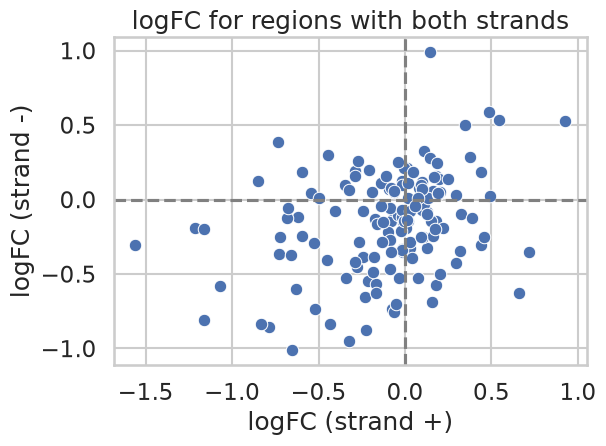

In [81]:
# consequence of strand on regional activity
both_strand_regions = tested_ngn2_element_activity_df.loc[tested_ngn2_element_activity_df["region_id"].isin(duplicated_based_on_strand)].copy()
# got all relevant sequences only interested on ref "+" and ref "-" => drop all ALT
both_strand_region_ref = both_strand_regions.loc[~both_strand_regions["name"].str.contains(":ALT_", na=False)].copy()
both_strand_region_ref

# scatter plot of logFC for both strands
pivot = both_strand_region_ref.pivot(index="region_id", columns="strand", values="logFC")
pivot = pivot.rename(columns={"+": "logFC_plus", "-": "logFC_minus"})
pivot = pivot.dropna(subset=["logFC_plus", "logFC_minus"])
pivot["region_id"] = pivot.index
pivot = pivot.reset_index(drop=True)

sns.scatterplot(data=pivot, x="logFC_plus", y="logFC_minus")
plt.title("logFC for regions with both strands")
plt.xlabel("logFC (strand +)")
plt.ylabel("logFC (strand -)")
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.tight_layout()
plt.show()



#### Investigate the regions => 1. drop the alternative alleles

In [82]:
tested_ref_only_ngn2_element_activity_df = tested_ngn2_element_activity_df.loc[~tested_ngn2_element_activity_df["name"].str.contains(":ALT_", na=False)].copy()



# drop regions without information:
tested_ref_only_ngn2_element_activity_df = tested_ref_only_ngn2_element_activity_df.loc[
    tested_ref_only_ngn2_element_activity_df["normalized_activity_NGN2"].notna()
].copy()

In [83]:
print(f"Number of regions with all element information from tested group: {tested_ngn2_element_activity_df.shape[0]}")
print(f"Number of regions without alt alleles: {tested_ref_only_ngn2_element_activity_df.shape[0]}")


#

Number of regions with all element information from tested group: 65308
Number of regions without alt alleles: 24510


In [84]:
writing = False
output_path = "data/2603_80k_MPRA_ngn2_ref_only.tsv.gz"
if writing:
    tested_ref_only_ngn2_element_activity_df.to_csv(
        output_path,
        sep="\t",
        index=False,
    )

In [85]:
tested_ref_only_ngn2_element_activity_df["start"] = tested_ref_only_ngn2_element_activity_df["start"].astype(int)
tested_ref_only_ngn2_element_activity_df["end"] = tested_ref_only_ngn2_element_activity_df["end"].astype(int)
tested_ref_only_ngn2_element_activity_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,phastCons_mean,singleton_overlap_count,is_glutaNeuron_SCREEN_cCRE,region_id,size,covered,region_phyloP_sum,region_phyloP_mean0,region_phyloP_mean_covered,region_phyloP_fraction_covered
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,0.010167,37.0,False,chr1:2181843-2182113,270,270,-57.762,-0.213933,-0.213933,1.0
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.134044,31.0,False,chr1:2182439-2182709,270,270,-103.193,-0.382196,-0.382196,1.0
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,0.046904,34.0,False,chr1:2188389-2188659,270,270,-93.936,-0.347911,-0.347911,1.0
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,0.001030,37.0,False,chr1:2192636-2192906,270,270,-45.786,-0.169578,-0.169578,1.0
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,0.000415,23.0,False,chr1:2203380-2203650,270,270,-124.574,-0.461385,-0.461385,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24576,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,0.050596,24.0,False,chrX:154519466-154519736,270,270,-50.706,-0.187800,-0.187800,1.0
24577,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,0.025070,19.0,False,chrX:154539055-154539325,270,270,-73.179,-0.271033,-0.271033,1.0
24578,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,0.006426,24.0,False,chrX:154545000-154545270,270,270,-92.753,-0.343530,-0.343530,1.0
24579,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,0.033163,23.0,False,chrX:154549802-154550072,270,270,-49.781,-0.184374,-0.184374,1.0


In [86]:
tested_ref_only_ngn2_element_activity_df.columns.to_list()

['name',
 'sequence',
 'category',
 'class',
 'source',
 'ref',
 'chr',
 'start',
 'end',
 'strand',
 'variant_class',
 'variant_pos',
 'SPDI',
 'allele',
 'info',
 'normalized_name',
 'logFC',
 'adj.P.Val',
 'normalized_activity_NGN2',
 'significant_region_NGN2',
 'effect_direction_NGN2',
 'region_info',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'gene_id',
 'closest_tss_gene_name',
 'tss_distance',
 'associated_gene_name',
 'gene_set',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'dELS_is_brain_SCREEN_cCRE_group',
 'CA-only_is_brain_SCREEN_cCRE_group',
 'PLS_is_brain_SCREEN_cCRE_group',
 'pELS_is_brain_SCREEN_cCRE_group',
 'CA-H3K4me3_is_brain_SCREEN_cCRE_group',
 'CA-TF_is_brain_SCREEN_cCRE_group',
 'CA-only_is_heart_SCREEN_cCRE_group',
 'PLS_is_heart_SCREEN

In [87]:
GENE_SET_ORDER = ["neuro", "cardiac", "cava", "random"]

df = tested_ref_only_ngn2_element_activity_df.copy()

# preprocess
region_df = preprocess_design_df(
    df,
    gene_col="associated_gene_name",
    gene_set_col="gene_set",
    active_logic="significant_region_NGN2",
    excitatory_col="is_glutaNeuron_SCREEN_cCRE",
)
print(f"Number of region after procedssing: {region_df.shape[0]}")

# add constraint
constraint_regions_path = "data/RoCCs.bed.gz"
region_df = add_rocc_constraint_annotation(
    region_df,
    rocc_path=constraint_regions_path,
    chr_col="chr",
    start_col="start",
    end_col="end",
    region_id_col="region_id",
)
print(f"Number of region after merge: {region_df.shape[0]}")
# combine annotations
region_df["is_constrained_brain_SCREEN"] = (
    region_df["is_constrained"] & region_df["is_brain_SCREEN_cCRE"]
)
print("Note: The region df has exploded gene set information meaning the region id column is not unique anymore. => filter properly and use unique when interested in a number")

Number of region after procedssing: 25533
Number of region after merge: 25533
Note: The region df has exploded gene set information meaning the region id column is not unique anymore. => filter properly and use unique when interested in a number


In [88]:
# expression:

# downloaded here: https://www.proteinatlas.org/humanproteome/brain/data#hpa_brain_regions_rna
hpa_brain_path = "data/rna_brain_region_hpa.tsv.gz"
hpa_brain_df = pd.read_csv(hpa_brain_path, sep="\t")

brain_region_cerebral_cortex_nTPMs = (
    hpa_brain_df.loc[hpa_brain_df["Brain region"] == "cerebral cortex"]
    .groupby("Gene name")["nTPM"]
    .max()
    .reset_index()
)

# rename nTPM => linked_gene_nTPM_cerebral_cortex
brain_region_cerebral_cortex_nTPMs = brain_region_cerebral_cortex_nTPMs.rename(
    columns={"nTPM": "linked_gene_nTPM_cerebral_cortex"}
)


region_df = (
    region_df.merge(
        brain_region_cerebral_cortex_nTPMs,
        left_on="associated_gene_name",
        right_on="Gene name",
        how="left",
    )
).drop(columns=["Gene name"])


# check for the NA genes:
na_genes = region_df.loc[
    region_df["linked_gene_nTPM_cerebral_cortex"].isna(),
    "associated_gene_name",
].unique()
print(f"Number of associated genes with NA cerebral cortex expression: {len(na_genes)}")
print(f"Associated genes with NA cerebral cortex expression: {na_genes}")

Number of associated genes with NA cerebral cortex expression: 3
Associated genes with NA cerebral cortex expression: <ArrowStringArray>
['LINC01033', 'LINC01583', 'LINC01626']
Length: 3, dtype: str


In [89]:
expression_threshold = 5
region_df["is_expressed_in_cortex"] = region_df["linked_gene_nTPM_cerebral_cortex"] >= expression_threshold



#### for all genes results:
- mpra_design:
- extract the genes (given by a gene list) from gene code genes
https://github.com/kircherlab/MPRA_design/blob/171210e93f2da62bf1c9e3ce597f5ee3ad8f9bfa/workflow/scripts/extract_genes.py
- collapse tss:
```

rule genes_extract_tss:
    """
    Extract all the TSS from level 1 transcripts from the GTF file
    """
    conda:
        "../envs/default.yaml"
    input:
        "results/genes/gencode.gtf.gz",
    output:
        "results/genes/gencode.tss.bed.gz",
    log:
        "results/logs/genes/extract_tss.log",
    shell:
        """
        zcat {input} | \
        awk '$3 == "transcript"' | \
        awk -v "OFS=\\t" '{{start = $4; if ($7 == "-"){{start = $5}}; print $1,start-1,start,$16"|"$10,".",$7}}' | \
        sed 's/[\\";]//g' | \
        sort -k1,1 -k2,2n | \
        bgzip -c > {output} 2> {log}
        """

rule genes_collapse_tss_per_gene:
    """

    """
    conda:
        "../envs/default.yaml"
    input:
        "results/genes/gencode.tss.bed.gz",
    output:
        "results/genes/gencode.tss.collaped.bed.gz",
    log:
        "results/logs/genes/collapse_tss_per_gene.log",
    shell:
        """
        zcat {input} | \
        sort -k4,4 -k1,1 -k 2,2n | \
        awk -v "OFS=\\t" 'BEGIN {{
            id="";chr="";start="";end="";strand=""
        }}{{
            if ($4 == id) {{
                end=$3
            }} else {{
                if (NR > 1) {{
                    print chr,start,end,id,".",strand;
                }};
                id=$4;chr=$1;start=$2;end=$3;strand=$6;
            }}
        }} END {{
            print chr,start,end,id,".",strand
        }}' | \
        sort -k1,1 -k2,2n | \
        bgzip -c > {output} 2> {log}
        """

rule genes_adjust_window:
    """
    Adjust search-window in gene bedfile.
    """
    conda:
        "../envs/default.yaml"
    input:
        gene_tss="results/genes/gencode.tss.collaped.bed.gz",
        genome=config["global"]["genome"],
    output:
        "results/genes/gencode.tss-window.bed.gz",
    log:
        "results/logs/genes/extract_tss_per_gene_window.log",
    shell:
        """
        bedtools slop -i {input.gene_tss} -g {input.genome} -b 50000 | bgzip -c > {output} 2> {log}
        """
```
Keep going here about the code for the all genes dataframe


In [90]:
def load_collapsed_tss(path):
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=["chr", "start", "end", "gene_id", "score", "strand"],
    )

    # add chr prefix if not present
    if not df["chr"].iloc[0].startswith("chr"):
        df["chr"] = "chr" + df["chr"].astype(str)

        # handle mitochondrial if present
        df["chr"] = df["chr"].replace({"chrMT": "chrM", "chrMt": "chrM"})

    # extract gene name
    df["gene_name"] = df["gene_id"].str.split("|").str[0]

    return df[["chr", "start", "end", "strand", "gene_name"]]


def add_tss_window(df, window=50000):
    x = df.copy()
    x["start"] = (x["start"] - window).clip(lower=0)
    x["end"] = x["end"] + window
    return x


def load_ccres(path):
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=["chr", "start", "end", "dhs_id", "ccre_id", "annotation"],
    )
    return df


def make_ccres_both_strands(df):
    plus = df.copy()
    plus["strand"] = "+"

    minus = df.copy()
    minus["strand"] = "-"

    return pd.concat([plus, minus], ignore_index=True)


import pyranges as pr


def intersect_ccres_with_genes(ccres_df, genes_df):
    ccres_pr = pr.PyRanges(
        ccres_df.rename(
            columns={
                "chr": "Chromosome",
                "start": "Start",
                "end": "End",
                "strand": "Strand",
            }
        )
    )
    # workaround: pandas>=3.0 groupby(observed=False) leaves an empty
    # ("."-strand) group per chromosome that pyranges 0.1.4's join()
    # does not skip, raising KeyError("."). Drop empty groups first.
    ccres_pr.__dict__["dfs"] = {k: v for k, v in ccres_pr.dfs.items() if not v.empty}

    genes_pr = pr.PyRanges(
        genes_df.rename(
            columns={
                "chr": "Chromosome",
                "start": "Start",
                "end": "End",
                "strand": "Strand",
            }
        )
    )
    genes_pr.__dict__["dfs"] = {k: v for k, v in genes_pr.dfs.items() if not v.empty}

    ov = ccres_pr.join(genes_pr, strandedness="same").as_df()

    return ov


def build_all_genes_region_df(ov):
    df = ov.copy()

    df["region_id"] = (
        df["Chromosome"].astype(str)
        + ":"
        + df["Start"].astype(str)
        + "-"
        + df["End"].astype(str)
        + "("
        + df["Strand"].astype(str)
        + ")_"
        + df["gene_name"].astype(str)
    )

    out = df.rename(
        columns={
            "Chromosome": "chr",
            "Start": "start",
            "End": "end",
            "Strand": "strand",
        }
    )

    return out[
        [
            "chr",
            "start",
            "end",
            "strand",
            "gene_name",
            "region_id",
            "ccre_id",
        ]
    ]

In [91]:
# 1. Load TSS
tss = load_collapsed_tss(
    "data/gencode.v42.transcripts.collapsed.bed.gz"
)

print("TSS chromosomes:", sorted(tss["chr"].unique())[:5])

# 2. Add window
tss_window = add_tss_window(tss, window=50000)

# 3. Load cCREs
ccres = load_ccres(
    "data/GRCh38-cCREs_screen_v3_no_CTCT_bound.bed.gz"
)
print("cCRE chromosomes:", sorted(ccres["chr"].unique())[:5])

TSS chromosomes: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13']
cCRE chromosomes: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13']


In [92]:
# # 4. Duplicate strands
ccres = make_ccres_both_strands(ccres)

# 5. Intersect
ov = intersect_ccres_with_genes(ccres, tss_window)
# ov.shape[0] # 3,799,594

# 6. Build final dataframe
all_genes_region_df_unfiltered = build_all_genes_region_df(ov)

In [93]:
all_genes_region_df_unfiltered["ccre_id"].nunique()

563552

In [94]:
# load homopolymer, repeat, CTCF, and TSS filtered cCREs:
p1 = pd.read_csv("./data/homopolymer_repeat_tss_filtered_screen_v3_no_CTCT_bound.part1.tsv.gz", sep="\t")
p2 = pd.read_csv("./data/homopolymer_repeat_tss_filtered_screen_v3_no_CTCT_bound.part2.tsv.gz", sep="\t")
ccres_with_failiar = pd.concat([p1, p2], ignore_index=True)

filtered_ccres = ccres_with_failiar.loc[~ccres_with_failiar["failed"]].copy()
filtered_ccres

# 4. Duplicate strands
filtered_ccres_strand = make_ccres_both_strands(
    filtered_ccres[["chrom", "start", "end", "ID"]]
).rename(columns={"chrom": "chr", "ID": "ccre_id"})

# 5. Intersect
filtered_overlap = intersect_ccres_with_genes(filtered_ccres_strand, tss_window)
# filtered_overlap.shape[0] # 3,799,594
ov_unique = filtered_overlap.drop_duplicates(subset=["gene_name", "ccre_id"])
# 6. Build final dataframe
all_genes_region_df_filtered_cCREs = build_all_genes_region_df(ov_unique)

In [95]:
all_genes_region_df_filtered_cCREs["ccre_id"].nunique()

462887

In [96]:
all_genes_region_df = all_genes_region_df_filtered_cCREs.copy()

In [97]:
all_genes_region_df.sample(5)["gene_name"].to_list()

['ENSG00000251193', 'ENSG00000285849', 'U4', 'ENSG00000256085', 'SYBU']

In [98]:
all_genes_region_df

,chr,start,end,strand,gene_name,region_id,ccre_id
0,chr1,605330,605668,+,ENSG00000235146,chr1:605330-605668(+)_ENSG00000235146,EH38E2776534
1,chr1,605330,605668,+,MTND1P23,chr1:605330-605668(+)_MTND1P23,EH38E2776534
2,chr1,605330,605668,+,MTND2P28,chr1:605330-605668(+)_MTND2P28,EH38E2776534
3,chr1,605330,605668,+,MTCO1P12,chr1:605330-605668(+)_MTCO1P12,EH38E2776534
4,chr1,605330,605668,+,MTCO2P12,chr1:605330-605668(+)_MTCO2P12,EH38E2776534
...,...,...,...,...,...,...,...
1526399,chrY,21214502,21214832,-,NEFLP1,chrY:21214502-21214832(-)_NEFLP1,EH38E2776372
1526400,chrY,21252420,21252698,-,NEFLP1,chrY:21252420-21252698(-)_NEFLP1,EH38E3951202
1526401,chrY,21252996,21253278,-,NEFLP1,chrY:21252996-21253278(-)_NEFLP1,EH38E3951203
1526402,chrY,21839503,21839853,-,OFD1P16Y,chrY:21839503-21839853(-)_OFD1P16Y,EH38E3951242


In [99]:
gene_names = all_genes_region_df["gene_name"]
unique_gene_list = gene_names.nunique()

# genes containing ENSG
ensg_genes = gene_names[gene_names.str.startswith("ENSG")].unique()
non_ensg_genes = gene_names[~gene_names.str.startswith("ENSG")].unique()

print("Total unique:", unique_gene_list)

print("ENSG-like:", ensg_genes.shape[0])

print("Non-ENSG:", non_ensg_genes.shape[0])

Total unique: 59351
ENSG-like: 20246
Non-ENSG: 39105


In [100]:
# expression
all_genes_region_df = all_genes_region_df.merge(
    brain_region_cerebral_cortex_nTPMs,
    left_on="gene_name",
    right_on="Gene name",
    how="left",
).drop(columns=["Gene name"])

all_genes_region_df["is_expressed_in_cortex"] = (
    all_genes_region_df["linked_gene_nTPM_cerebral_cortex"] >= 5
)

In [101]:
# constraint
all_genes_region_df = add_rocc_constraint_annotation(
    all_genes_region_df,
    rocc_path=constraint_regions_path,
    chr_col="chr",
    start_col="start",
    end_col="end",
    region_id_col="region_id",
)


# gene set label
all_genes_region_df["gene_set"] = "all"

In [102]:
all_genes_region_df_hpa_matchable = all_genes_region_df.loc[
    all_genes_region_df["linked_gene_nTPM_cerebral_cortex"].notna()
].copy()

all_genes_region_df_hpa_matchable = all_genes_region_df_hpa_matchable.rename(
    columns={"ccre_id": "SCREEN_ID"}
)

all_genes_region_df_hpa_matchable

,chr,start,end,strand,gene_name,region_id,SCREEN_ID,linked_gene_nTPM_cerebral_cortex,is_expressed_in_cortex,n_bp_constrained,frac_bp_constrained,is_constrained,gene_set
65,chr1,912146,912486,+,SAMD11,chr1:912146-912486(+)_SAMD11,EH38E2776613,26.1,True,0,0.0,False,all
66,chr1,912146,912486,+,KLHL17,chr1:912146-912486(+)_KLHL17,EH38E2776613,9.6,True,0,0.0,False,all
71,chr1,913769,914022,+,SAMD11,chr1:913769-914022(+)_SAMD11,EH38E2776616,26.1,True,0,0.0,False,all
72,chr1,913769,914022,+,KLHL17,chr1:913769-914022(+)_KLHL17,EH38E2776616,9.6,True,0,0.0,False,all
76,chr1,932202,932507,+,SAMD11,chr1:932202-932507(+)_SAMD11,EH38E2776657,26.1,True,0,0.0,False,all
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522298,chrY,13415665,13415825,-,UTY,chrY:13415665-13415825(-)_UTY,EH38E3950733,6.7,True,0,0.0,False,all
1522299,chrY,13416011,13416162,-,UTY,chrY:13416011-13416162(-)_UTY,EH38E3950734,6.7,True,0,0.0,False,all
1522300,chrY,13424973,13425308,-,UTY,chrY:13424973-13425308(-)_UTY,EH38E2775694,6.7,True,0,0.0,False,all
1522301,chrY,13429199,13429377,-,UTY,chrY:13429199-13429377(-)_UTY,EH38E2775696,6.7,True,0,0.0,False,all


In [103]:
all_genes_region_df_hpa_matchable.groupby("gene_name")["SCREEN_ID"].size().reset_index(name="n_regions")["n_regions"].mean()

np.float64(33.26714509526457)

In [104]:


gene_names = all_genes_region_df_hpa_matchable["gene_name"]
unique_gene_list = gene_names.nunique()

# genes containing ENSG
ensg_genes = gene_names[gene_names.str.startswith("ENSG")].unique()
non_ensg_genes = gene_names[~gene_names.str.startswith("ENSG")].unique()

print("Total unique:", unique_gene_list)

print("ENSG-like:", ensg_genes.shape[0])

print("Non-ENSG:", non_ensg_genes.shape[0])

Total unique: 19787
ENSG-like: 343
Non-ENSG: 19444


In [105]:
print(all_genes_region_df_hpa_matchable.head(n=2).to_string())

     chr   start     end strand gene_name                     region_id     SCREEN_ID  linked_gene_nTPM_cerebral_cortex  is_expressed_in_cortex  n_bp_constrained  frac_bp_constrained  is_constrained gene_set
65  chr1  912146  912486      +    SAMD11  chr1:912146-912486(+)_SAMD11  EH38E2776613                              26.1                    True                 0                  0.0           False      all
66  chr1  912146  912486      +    KLHL17  chr1:912146-912486(+)_KLHL17  EH38E2776613                               9.6                    True                 0                  0.0           False      all


In [106]:
# combine the region_df and the all_genes_region_df_hpa_matchable to plot the group all genes in HPA to the comparison of gene sets
hpa_df = all_genes_region_df_hpa_matchable.copy()
hpa_df["gene_set"] = "HPA"

hpa_df = add_SCREEN_CRE_info(
    hpa_df,
    config_info="gluta_screen_active_cre",
    new_name="is_excitatory_SCREEN_cCRE",
    screen_id_col="SCREEN_ID",
)

hpa_df = add_SCREEN_CRE_info(
    hpa_df,
    config_info="brain_screen_active_cre",
    new_name="is_brain_SCREEN_cCRE",
    screen_id_col="SCREEN_ID",
)

print(hpa_df["is_brain_SCREEN_cCRE"].mean())
print(hpa_df["is_excitatory_SCREEN_cCRE"].mean())

0.26450459319080544
0.01920982230344683


In [107]:
region_df.groupby("associated_gene_name")["SCREEN_ID"].size().reset_index(name="n_regions")[
    "n_regions"
].mean()

np.float64(48.72709923664122)

In [108]:
region_df.groupby("associated_gene_name")["SCREEN_ID"].nunique().reset_index(name="n_regions")[
    "n_regions"
].mean()

np.float64(46.774809160305345)

In [109]:
hpa_df_dedup = hpa_df.drop_duplicates(subset=["gene_name", "region_id"])
hpa_df_dedup

,chr,start,end,strand,gene_name,region_id,SCREEN_ID,linked_gene_nTPM_cerebral_cortex,is_expressed_in_cortex,n_bp_constrained,frac_bp_constrained,is_constrained,gene_set,is_excitatory_SCREEN_cCRE,is_brain_SCREEN_cCRE
0,chr1,912146,912486,+,SAMD11,chr1:912146-912486(+)_SAMD11,EH38E2776613,26.1,True,0,0.0,False,HPA,False,False
1,chr1,912146,912486,+,KLHL17,chr1:912146-912486(+)_KLHL17,EH38E2776613,9.6,True,0,0.0,False,HPA,False,False
2,chr1,913769,914022,+,SAMD11,chr1:913769-914022(+)_SAMD11,EH38E2776616,26.1,True,0,0.0,False,HPA,False,False
3,chr1,913769,914022,+,KLHL17,chr1:913769-914022(+)_KLHL17,EH38E2776616,9.6,True,0,0.0,False,HPA,False,False
4,chr1,932202,932507,+,SAMD11,chr1:932202-932507(+)_SAMD11,EH38E2776657,26.1,True,0,0.0,False,HPA,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
658252,chrY,13415665,13415825,-,UTY,chrY:13415665-13415825(-)_UTY,EH38E3950733,6.7,True,0,0.0,False,HPA,False,False
658253,chrY,13416011,13416162,-,UTY,chrY:13416011-13416162(-)_UTY,EH38E3950734,6.7,True,0,0.0,False,HPA,False,False
658254,chrY,13424973,13425308,-,UTY,chrY:13424973-13425308(-)_UTY,EH38E2775694,6.7,True,0,0.0,False,HPA,False,False
658255,chrY,13429199,13429377,-,UTY,chrY:13429199-13429377(-)_UTY,EH38E2775696,6.7,True,0,0.0,False,HPA,False,False


In [110]:
combined_df = pd.concat([region_df, hpa_df], ignore_index=True)
combined_df

,associated_gene_name,gene_set,region_id,chr,start,end,strand,SCREEN_ID,normalized_activity_NGN2,is_brain_SCREEN_cCRE,is_excitatory_SCREEN_cCRE,is_active_region,n_bp_constrained,frac_bp_constrained,is_constrained,is_constrained_brain_SCREEN,linked_gene_nTPM_cerebral_cortex,is_expressed_in_cortex,gene_name
0,AARS1,neuro,chr16:70213614-70213884(-)_AARS1,chr16,70213614,70213884,-,EH38E3188739,-0.178311,False,False,False,0,0.000000,False,False,146.9,True,NaN
1,AARS1,neuro,chr16:70223326-70223596(-)_AARS1,chr16,70223326,70223596,-,EH38E1825123,0.105961,False,False,False,0,0.000000,False,False,146.9,True,NaN
2,AARS1,neuro,chr16:70230260-70230530(-)_AARS1,chr16,70230260,70230530,-,EH38E3188744,0.077677,False,False,False,0,0.000000,False,False,146.9,True,NaN
3,AARS1,neuro,chr16:70276484-70276754(-)_AARS1,chr16,70276484,70276754,-,EH38E1825144,-3.230881,True,False,True,96,0.355556,True,True,146.9,True,NaN
4,AARS1,neuro,chr16:70277149-70277419(-)_AARS1,chr16,70277149,70277419,-,EH38E3188758,-0.598835,False,False,False,7,0.025926,True,False,146.9,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683785,NaN,HPA,chrY:13415665-13415825(-)_UTY,chrY,13415665,13415825,-,EH38E3950733,NaN,False,False,NaN,0,0.000000,False,NaN,6.7,True,UTY
683786,NaN,HPA,chrY:13416011-13416162(-)_UTY,chrY,13416011,13416162,-,EH38E3950734,NaN,False,False,NaN,0,0.000000,False,NaN,6.7,True,UTY
683787,NaN,HPA,chrY:13424973-13425308(-)_UTY,chrY,13424973,13425308,-,EH38E2775694,NaN,False,False,NaN,0,0.000000,False,NaN,6.7,True,UTY
683788,NaN,HPA,chrY:13429199-13429377(-)_UTY,chrY,13429199,13429377,-,EH38E2775696,NaN,False,False,NaN,0,0.000000,False,NaN,6.7,True,UTY


In [111]:
print(combined_df.sample(3).to_string())


# ##### Visualizations all and mpra design overview

       associated_gene_name gene_set                           region_id    chr     start       end strand     SCREEN_ID  normalized_activity_NGN2  is_brain_SCREEN_cCRE  is_excitatory_SCREEN_cCRE is_active_region  n_bp_constrained  frac_bp_constrained  is_constrained is_constrained_brain_SCREEN  linked_gene_nTPM_cerebral_cortex  is_expressed_in_cortex gene_name
20727                SLC6A1    neuro    chr3:10978564-10978834(+)_SLC6A1   chr3  10978564  10978834      +  EH38E3495331                  0.277445                 False                      False            False                 0                  0.0           False                       False                             192.4                    True       NaN
161019                  NaN      HPA  chr3:58234783-58234950(-)_DNASE1L3   chr3  58234783  58234950      -  EH38E2206143                       NaN                  True                      False              NaN                 0                  0.0           False     

In [112]:
region_df = region_df.drop_duplicates(subset=["associated_gene_name", "gene_set", "region_id"])
region_df

,associated_gene_name,gene_set,region_id,chr,start,end,strand,SCREEN_ID,normalized_activity_NGN2,is_brain_SCREEN_cCRE,is_excitatory_SCREEN_cCRE,is_active_region,n_bp_constrained,frac_bp_constrained,is_constrained,is_constrained_brain_SCREEN,linked_gene_nTPM_cerebral_cortex,is_expressed_in_cortex
0,AARS1,neuro,chr16:70213614-70213884(-)_AARS1,chr16,70213614,70213884,-,EH38E3188739,-0.178311,False,False,False,0,0.000000,False,False,146.9,True
1,AARS1,neuro,chr16:70223326-70223596(-)_AARS1,chr16,70223326,70223596,-,EH38E1825123,0.105961,False,False,False,0,0.000000,False,False,146.9,True
2,AARS1,neuro,chr16:70230260-70230530(-)_AARS1,chr16,70230260,70230530,-,EH38E3188744,0.077677,False,False,False,0,0.000000,False,False,146.9,True
3,AARS1,neuro,chr16:70276484-70276754(-)_AARS1,chr16,70276484,70276754,-,EH38E1825144,-3.230881,True,False,True,96,0.355556,True,True,146.9,True
4,AARS1,neuro,chr16:70277149-70277419(-)_AARS1,chr16,70277149,70277419,-,EH38E3188758,-0.598835,False,False,False,7,0.025926,True,False,146.9,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25528,ZNF462,neuro,chr9:107038939-107039209(+)_ZNF462,chr9,107038939,107039209,+,EH38E3899614,-1.435521,False,False,False,0,0.000000,False,False,50.3,True
25529,ZNF462,neuro,chr9:107039906-107040176(+)_ZNF462,chr9,107039906,107040176,+,EH38E2715190,0.221181,False,False,False,0,0.000000,False,False,50.3,True
25530,ZNF462,neuro,chr9:107046720-107046990(+)_ZNF462,chr9,107046720,107046990,+,EH38E2715195,0.560608,False,False,False,0,0.000000,False,False,50.3,True
25531,ZNF462,neuro,chr9:107050168-107050438(+)_ZNF462,chr9,107050168,107050438,+,EH38E3899618,-0.264545,False,False,False,0,0.000000,False,False,50.3,True


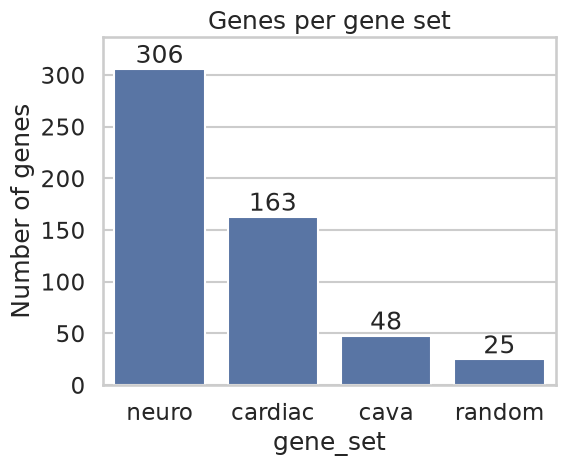

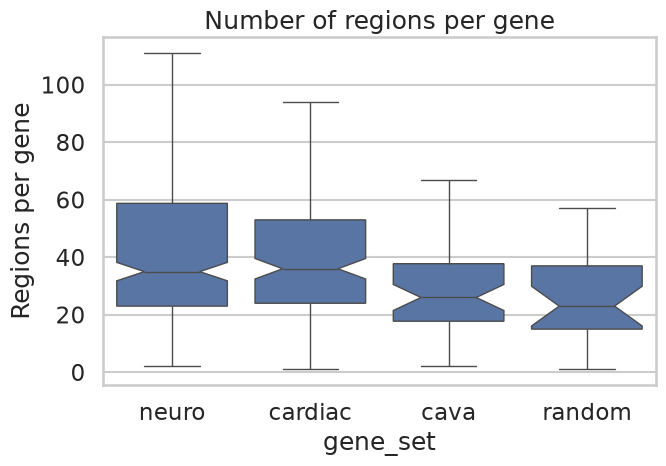

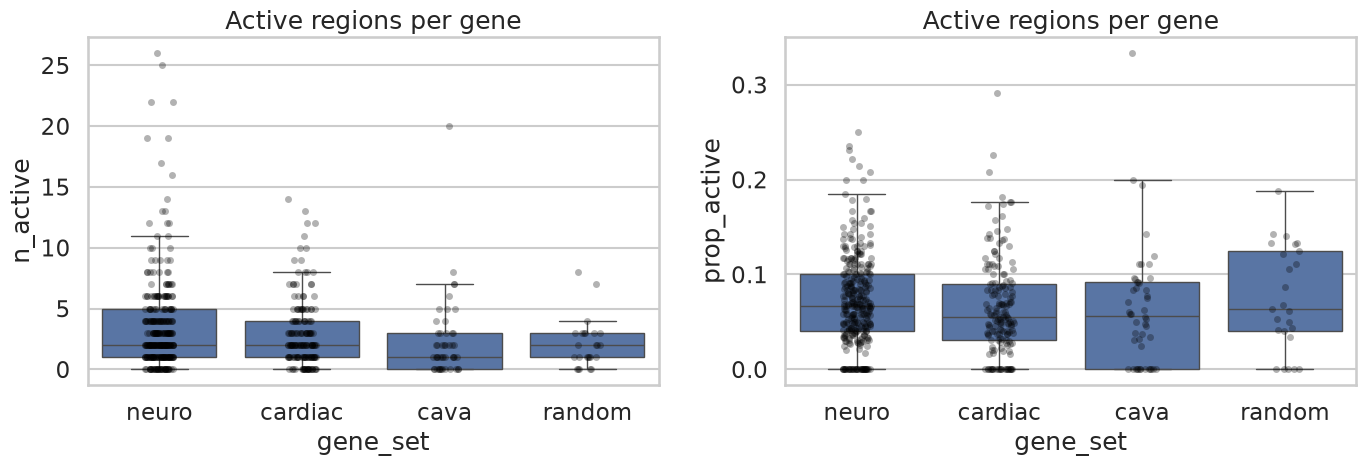

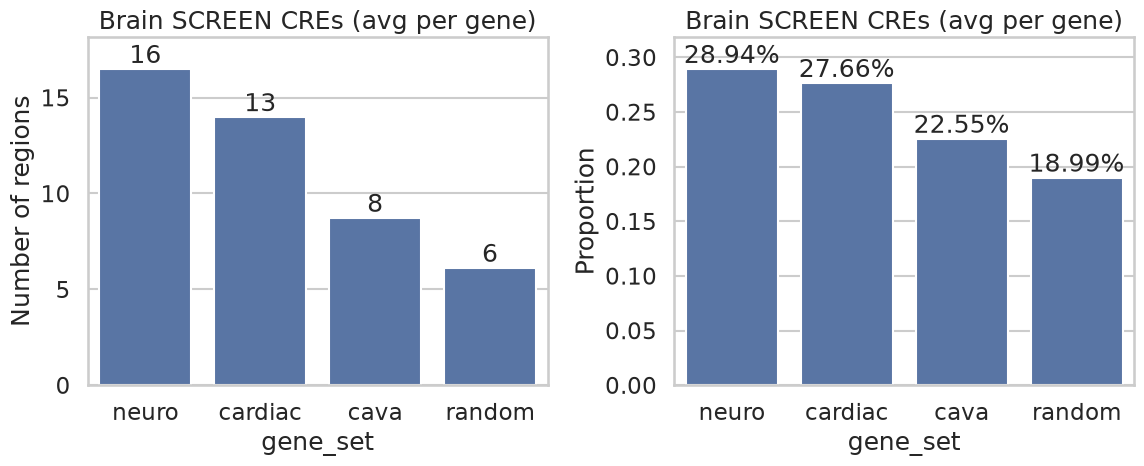

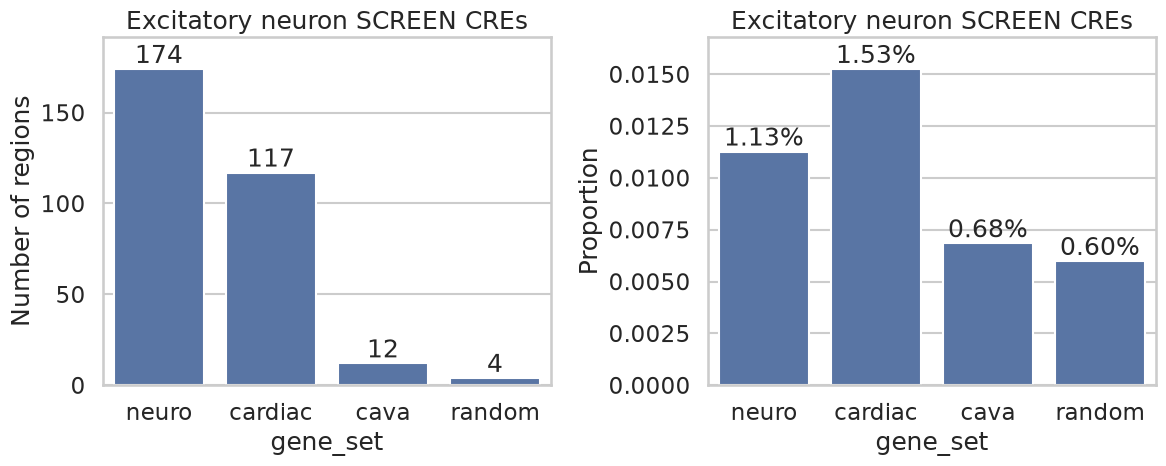

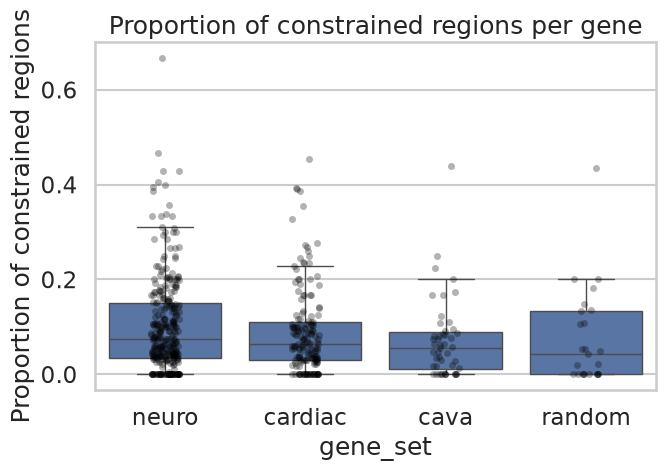

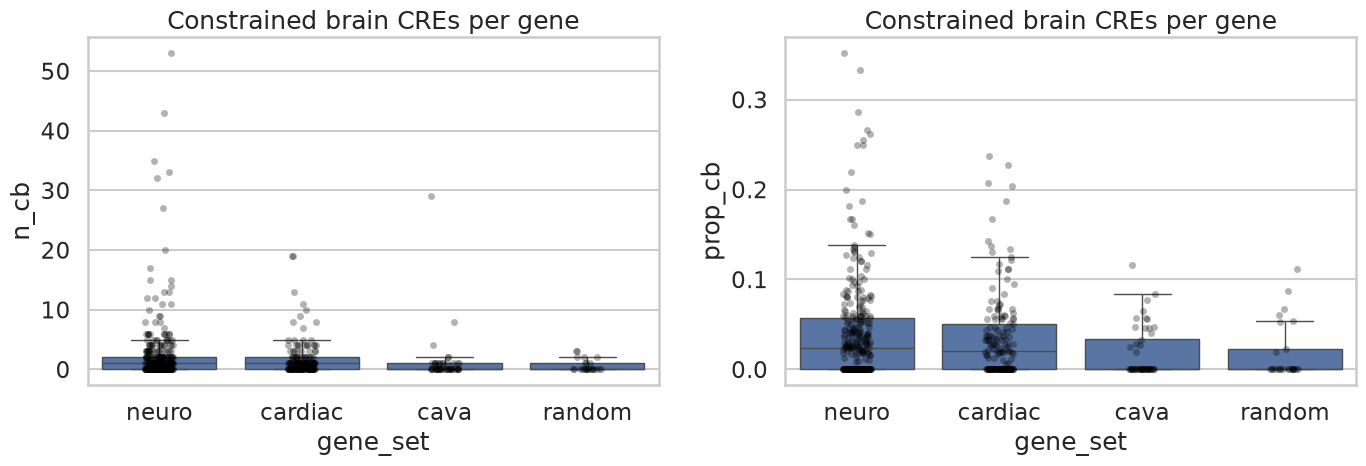

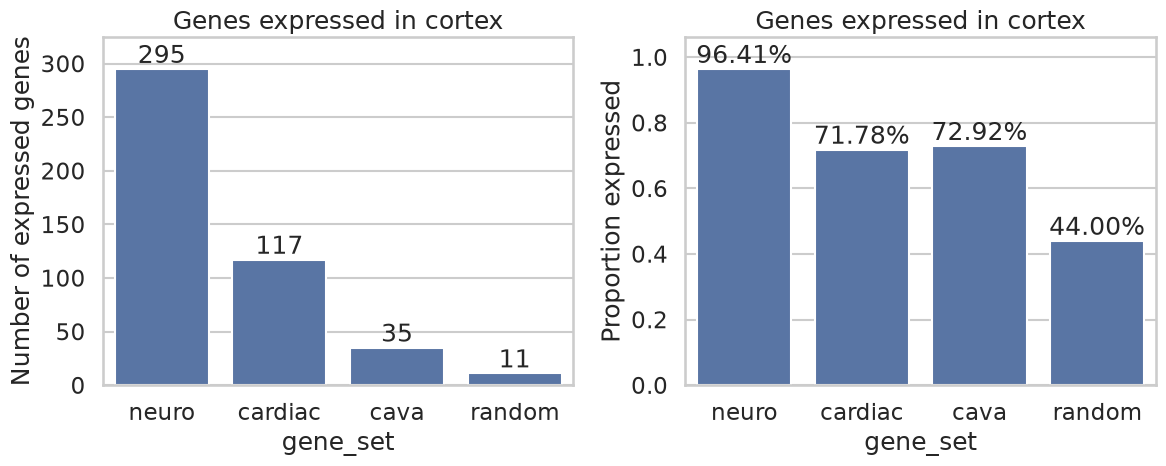

In [113]:
GENE_SET_ORDER = ["neuro", "cardiac", "cava", "random"]

OUTPUT_DIR = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/overview"

fig1 = panel1_genes(region_df, gene_set_list=["neuro", "cardiac", "cava", "random"], output_path=os.path.join(OUTPUT_DIR, "panel1_genes_per_gene_set_only_MPRA.png"), number_plot=True, prop_plot=False)
fig2 = panel2_regions_per_gene(region_df, with_stripplot=False, with_notches=True, output_path=os.path.join(OUTPUT_DIR, "panel2_regions_per_gene_only_MPRA.png"))
fig3 = panel3_active_regions(
    region_df, gene_set_list=["neuro", "cardiac", "cava", "random"], output_path=os.path.join(OUTPUT_DIR, "panel3_active_regions_only_MPRA.png")
)
fig4 = panel4_brain_SCREEN(region_df, gene_set_list=["neuro", "cardiac", "cava", "random"], output_path=os.path.join(OUTPUT_DIR, "panel4_brain_SCREEN_only_MPRA.png"))
fig5 = panel5_excit_SCREEN(region_df, output_path=os.path.join(OUTPUT_DIR, "panel5_excit_SCREEN_only_MPRA.png"))
fig6 = panel6_constraint(region_df, output_path=os.path.join(OUTPUT_DIR, "panel6_constraint_only_MPRA.png"))
fig7 = panel7_constraint_brain(region_df, output_path=os.path.join(OUTPUT_DIR, "panel7_constraint_brain_only_MPRA.png"))
fig_expr = panel_expressed_genes(region_df, output_path=os.path.join(OUTPUT_DIR, "panel_expressed_genes_only_MPRA.png"))

plt.show()

In [114]:
# merge "associated_gene_name" and "gene_name" if one of them is NA and the otherone has a value, otherwise throw an error
combined_df["gene_name"] = combined_df.apply(
    lambda row: row["associated_gene_name"]
    if pd.isna(row["gene_name"]) and not pd.isna(row["associated_gene_name"])
    else row["gene_name"],
    axis=1,
)

combined_df["gene_name"].isna().sum()




np.int64(0)

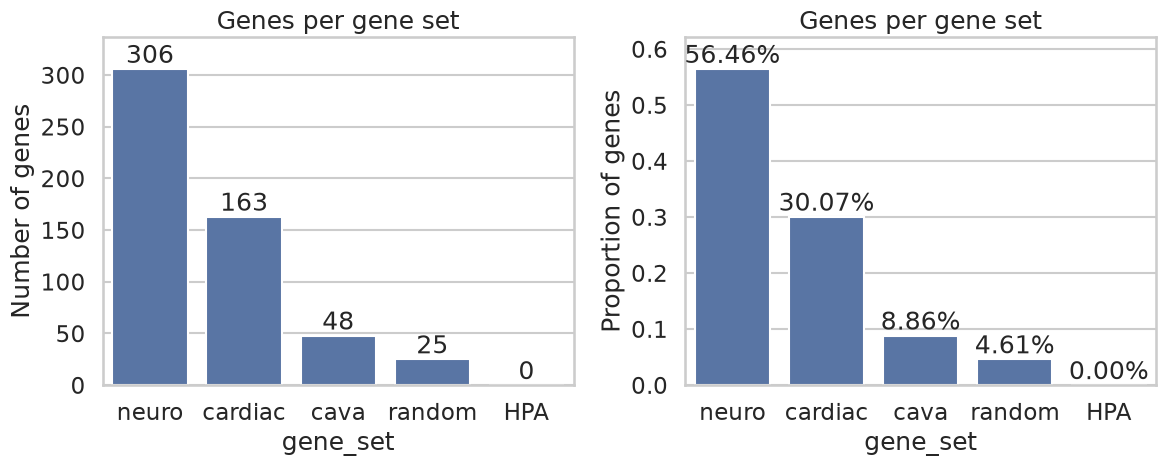

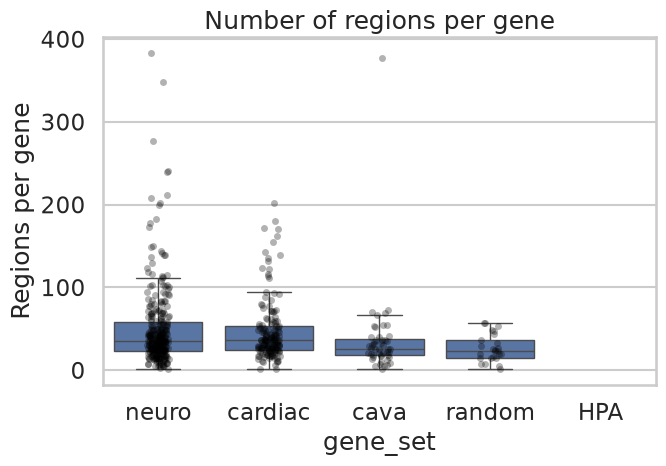

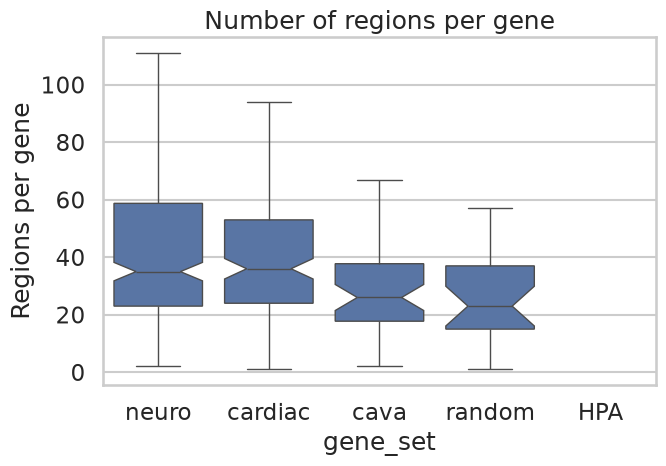

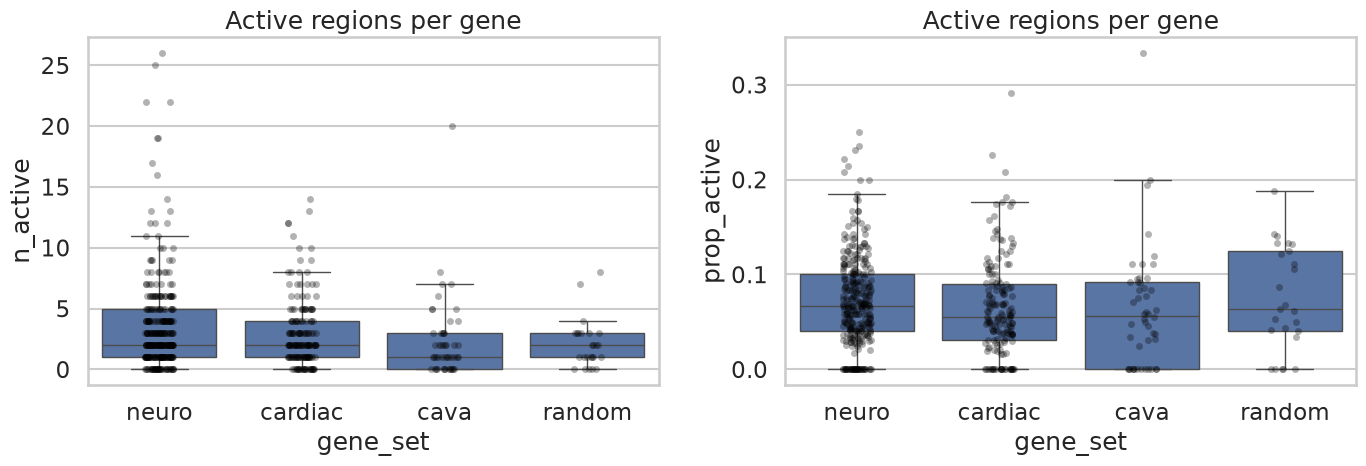

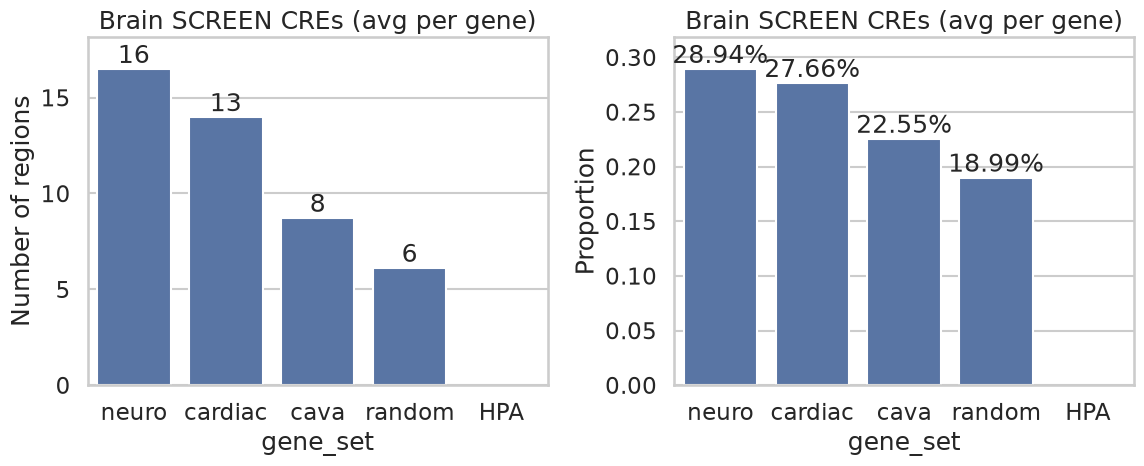

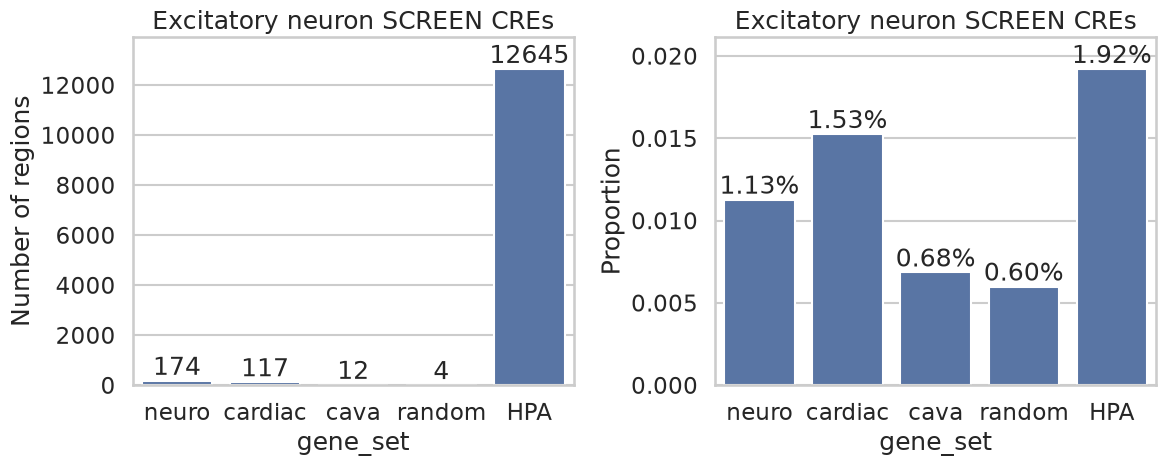

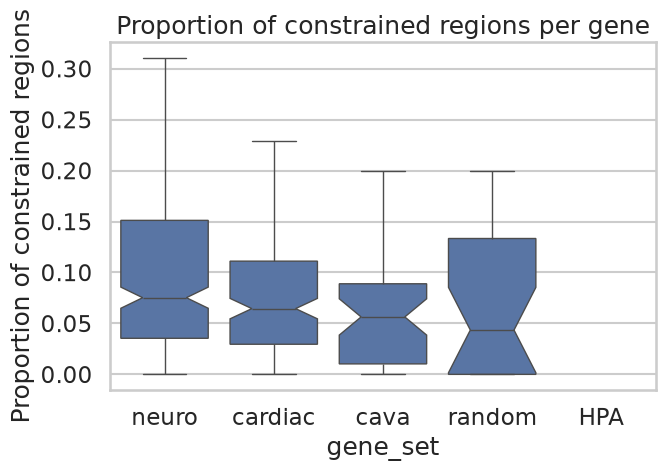

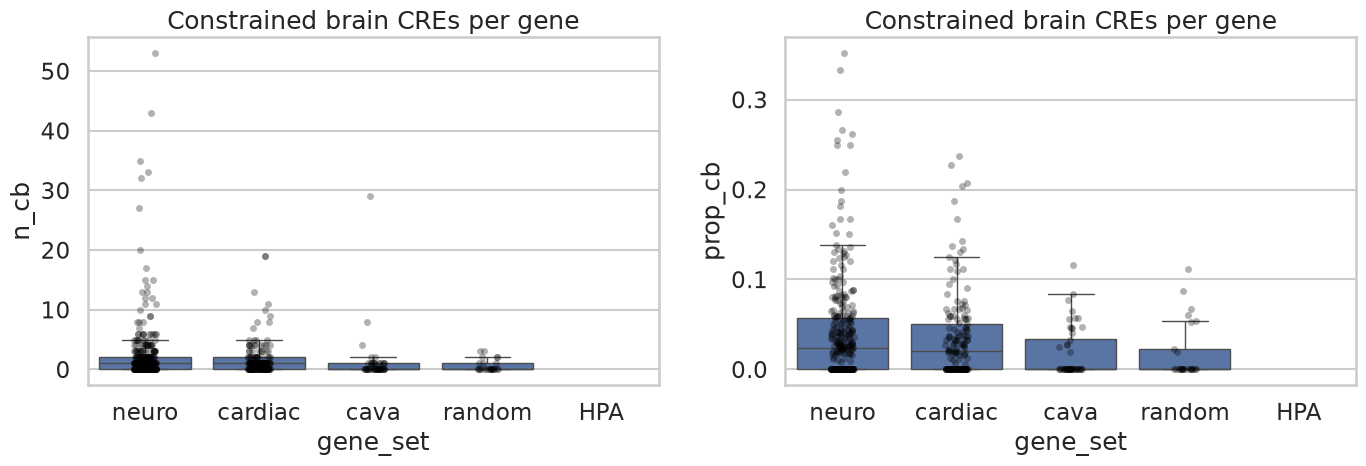

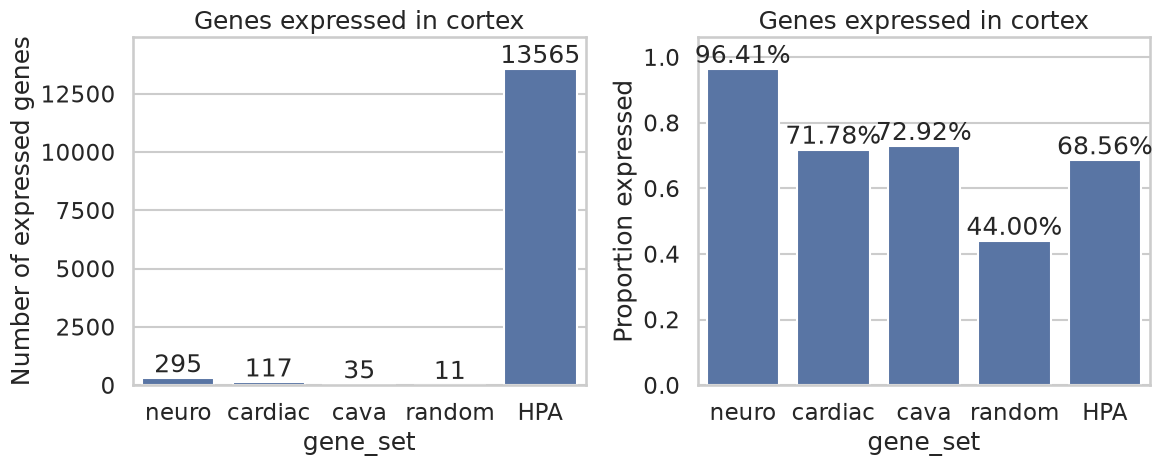

In [119]:
GENE_SET_ORDER = ["neuro", "cardiac", "cava", "random", "HPA"]

OUTPUT_DIR = "data/overview_panel"

fig1b = panel1_genes(combined_df, output_path=os.path.join(OUTPUT_DIR, "panel1_genes_per_gene_set_with_HPA.png"))
fig2 = panel2_regions_per_gene(combined_df, output_path=os.path.join(OUTPUT_DIR, "panel2_regions_per_gene_with_HPA.png"))
fig2a = panel2_regions_per_gene(combined_df, with_stripplot=False, with_notches=True, output_path=os.path.join(OUTPUT_DIR, "panel2_regions_per_gene_with_HPA_notches.png"))
fig3 = panel3_active_regions(region_df, gene_set_list=["neuro", "cardiac", "cava", "random"], output_path=os.path.join(OUTPUT_DIR, "panel3_active_regions_only_MPRA.png"))
fig4 = panel4_brain_SCREEN(
    combined_df, output_path=os.path.join(OUTPUT_DIR, "panel4_brain_SCREEN_with_HPA.png")
)
fig5 = panel5_excit_SCREEN(
    combined_df, output_path=os.path.join(OUTPUT_DIR, "panel5_excit_SCREEN_with_HPA.png")
)
fig6 = panel6_constraint(combined_df, output_path=os.path.join(OUTPUT_DIR, "panel6_constraint_with_HPA.png"), with_stripplot=False, with_notches=True)
fig7 = panel7_constraint_brain(combined_df, output_path=os.path.join(OUTPUT_DIR, "panel7_constraint_brain_with_HPA.png"))
fig_expr = panel_expressed_genes(combined_df, output_path=os.path.join(OUTPUT_DIR, "panel_expressed_genes_with_HPA.png"), gene_col="gene_name")

plt.show()

In [116]:
print(region_df.head(n=2).to_string())

  associated_gene_name gene_set                         region_id    chr     start       end strand     SCREEN_ID  normalized_activity_NGN2  is_brain_SCREEN_cCRE  is_excitatory_SCREEN_cCRE  is_active_region  n_bp_constrained  frac_bp_constrained  is_constrained  is_constrained_brain_SCREEN  linked_gene_nTPM_cerebral_cortex  is_expressed_in_cortex
0                AARS1    neuro  chr16:70213614-70213884(-)_AARS1  chr16  70213614  70213884      -  EH38E3188739                 -0.178311                 False                      False             False                 0                  0.0           False                        False                             146.9                    True
1                AARS1    neuro  chr16:70223326-70223596(-)_AARS1  chr16  70223326  70223596      -  EH38E1825123                  0.105961                 False                      False             False                 0                  0.0           False                        False            

In [117]:
active = region_df[region_df["is_active_region"]]

per_gene = (
    active.groupby(["gene_set", "associated_gene_name"])["region_id"]
    .nunique()
    .reset_index(name="n_active")
)

all_genes = region_df[["gene_set", "associated_gene_name"]].drop_duplicates()
per_gene = all_genes.merge(per_gene, how="left").fillna(0)

totals = (
    region_df.groupby(["gene_set", "associated_gene_name"])["region_id"]
    .nunique()
    .reset_index(name="total_regions")
)

per_gene = per_gene.merge(totals)
per_gene["prop_active"] = per_gene["n_active"] / per_gene["total_regions"]

In [118]:
print(region_df["is_constrained"].mean())

print(region_df.groupby("gene_set")["is_constrained"].agg(["mean", "sum", "count"]))

print(region_df["frac_bp_constrained"].describe())

0.09434849018916697
              mean   sum  count
gene_set                       
cardiac   0.079129   607   7671
cava      0.085568   150   1753
neuro     0.103879  1604  15441
random    0.071856    48    668
count    25533.000000
mean         0.030839
std          0.123999
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.851852
Name: frac_bp_constrained, dtype: float64
